## PROYECTO 2:ESTUDIO DE SEÑALES EEG DEL FUNCIONAMIENTO Y EL CONTROL DEL MOVIMIENTO (imaginería motora) CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
### Dataset: EEG Motor Movement/Imagery – PhysioNet / OpenNeuro ds004362
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]
#### **Laboratorio de Bioseñales – UdeA 2026-1**

> **Guía de lectura:** Este notebook implementa cada etapa del flujo de procesamiento de señales para BCI de forma independiente y paso a paso.


In [24]:
# ─── Importación de librerías ───────────────────────────────────────
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import signal as sp_signal
from scipy.signal import firwin, filtfilt, hilbert
from scipy.stats import shapiro, wilcoxon, ttest_rel

import mne
mne.set_log_level('WARNING')



In [25]:
# Machine Learning
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

try:
    import antropy as ant
    ANTROPY_OK = True
except ImportError:
    ANTROPY_OK = False
    print('antropy no instalado, se usará implementación propia para SampEn')

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('xgboost no instalado: pip install xgboost')


antropy no instalado, se usará implementación propia para SampEn


In [26]:

# ─── Parámetros globales ─────────────────────────────────────────────
SFREQ           = 160          # Hz
CANALES_INTERES = ['C3', 'Cz', 'C4']
L_FREQ, H_FREQ  = 8.0, 30.0   # Banda motora Mu + Beta
MU_BAND         = (8, 13)      # Hz
BETA_BAND       = (13, 30)     # Hz
TMIN, TMAX      = 0.0, 4.0     # Ventana de época (segundos)
M_WELCH         = 128          # Muestras por segmento Welch
S_WELCH         = M_WELCH // 2

# ─── Etiquetas de clases ─────────────────────────────────────────────
NOMBRES_CLASE = {0: 'Reposo (T0)', 1: 'Img Izq (T1)', 2: 'Img Der (T2)'}
COLORES_CLASE = {0: '#7F8C8D', 1: '#2980B9', 2: '#E74C3C'}


## **1. Configuración de rutas y búsqueda de archivos**
Solo usamos los archivos de **imaginación motora** (R04, R08, R12)
donde T1 = puño izquierdo y T2 = puño derecho.

In [27]:

RUTA_BASE = r'C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files'

N_SUJETOS        = 109
RUNS_IMAGINACION = ['R04', 'R08', 'R12']
todos_sujetos    = [f'S{i:03d}' for i in range(1, N_SUJETOS + 1)]

archivos_img = []
for sujeto in todos_sujetos:
    for run in RUNS_IMAGINACION:
        ruta = os.path.join(RUTA_BASE, sujeto, f'{sujeto}{run}.edf')
        if os.path.exists(ruta):
            archivos_img.append(ruta)

archivos_img.sort()
print(f'Archivos encontrados: {len(archivos_img)}')
print(f'Esperados: {N_SUJETOS * len(RUNS_IMAGINACION)}')
print('\nPrimeros 5:')
for a in archivos_img[:5]:
    print(' ', os.path.basename(a))


Archivos encontrados: 327
Esperados: 327

Primeros 5:
  S001R04.edf
  S001R08.edf
  S001R12.edf
  S002R04.edf
  S002R08.edf


## **2.Preprocesamiento de las señales.**


### **2.1Funciones de preprocesamiento (reutilizadas del Proyecto 1)**

Retomamos el pipeline del Proyecto 1:
- **CAR (Common Average Reference):** le resta a cada electrodo el promedio de todos.
  Esto cancela el ruido eléctrico que aparece igual en todos los canales
  (por ejemplo interferencia de red eléctrica a 60 Hz).
- **Filtro FIR pasabanda 8–30 Hz:** nos quedamos solo con las bandas Mu (8–13 Hz)
  y Beta (13–30 Hz) que son las que cambian durante la imaginación motora.
  Usamos `filtfilt` para que el filtro no cause desfase en la señal.
- **Segmentación en épocas:** cada evento (T0, T1, T2) se convierte en una
  ventana de 4 segundos que es nuestra unidad de análisis.

In [28]:
def aplicar_CAR(raw_obj):
    """
    Aplica Referencia Común a la Media (CAR).
    Elimina ruido eléctrico de modo común presente en todos los electrodos.
    x_CAR[n] = x_i[n] - (1/N) * sum_j(x_j[n])
    """
    raw_car = raw_obj.copy()
    datos   = raw_car.get_data()
    raw_car[:] = datos - datos.mean(axis=0)
    return raw_car


def aplicar_filtro_FIR(raw_car, l_freq=L_FREQ, h_freq=H_FREQ):
    """
    Filtro FIR pasabanda (8-30 Hz) de fase cero (filtfilt).
    Aísla bandas Mu y Beta eliminando artefactos de baja frecuencia y EMG.
    """
    fs     = raw_car.info['sfreq']
    delta_f = 2.0
    N_fir   = int(np.ceil(3.3 * fs / delta_f))
    if N_fir % 2 == 0:
        N_fir += 1
    b = firwin(N_fir, [l_freq, h_freq], fs=fs, window='hamming', pass_zero=False)

    raw_filt = raw_car.copy()
    datos    = raw_car.get_data()
    raw_filt[:] = filtfilt(b, [1.0], datos, axis=1)
    return raw_filt


def segmentar_epocas(raw_filt, tmin=TMIN, tmax=TMAX):
    """
    Segmenta la señal filtrada en épocas según marcadores.
    T0 = reposo, T1 = mano izquierda, T2 = mano derecha.
    Retorna dict {evento: Epochs MNE}
    """
    events, event_id = mne.events_from_annotations(raw_filt, verbose='WARNING')
    epochs_all = mne.Epochs(
        raw_filt, events, event_id=event_id,
        tmin=tmin, tmax=tmax,
        baseline=None, preload=True, verbose='WARNING'
    )
    epocas = {}
    for nombre in event_id.keys():
        try:
            epocas[str(nombre)] = epochs_all[str(nombre)]
        except:
            pass
    return epocas, event_id, epochs_all


def preprocesar_archivo(ruta_edf):
    """
    Flujo completo de preprocesamiento: carga → CAR → FIR → épocas.
    Retorna (epocas_dict, event_id) o (None, None) si falla.
    """
    try:
        raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose='WARNING')
        raw.rename_channels(lambda x: x.strip('.'))
        # Verificar que existan los canales de interés
        disponibles = set(raw.ch_names)
        if not all(c in disponibles for c in CANALES_INTERES):
            return None, None
        raw_car  = aplicar_CAR(raw)
        raw_filt = aplicar_filtro_FIR(raw_car)
        epocas, event_id, _ = segmentar_epocas(raw_filt)
        return epocas, event_id
    except Exception as e:
        return None, None

print("✔ Funciones de preprocesamiento definidas")

✔ Funciones de preprocesamiento definidas


## **3. Visualización de línea base: PSD y espectrograma**

Antes de extraer características, miramos visualmente la señal de un
sujeto de prueba para confirmar que el preprocesamiento funciona bien y para
justificar nuestras decisiones de diseño.

**¿Qué esperamos ver?**
- En la PSD: una caída de potencia en la banda Mu (8–13 Hz) en C3 o C4
  durante la imaginación motora respecto al reposo.
- En el espectrograma: esa misma caída pero en el tiempo, lo que confirma
  que los 4 segundos de ventana capturan bien el evento.

Visualizando: S001R04.edf


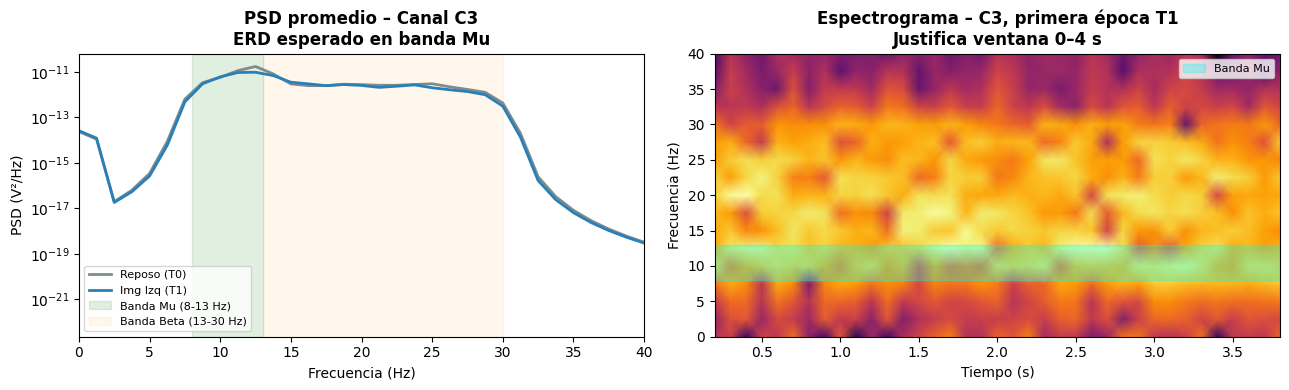

Figura guardada: figuras_P2/01_psd_espectrograma.png


In [29]:
# ── Cargar un solo archivo para visualización ────────────────────
if len(archivos_img) == 0:
    print('No se encontraron archivos. Revisar RUTA_BASE.')
else:
    ruta_prueba = archivos_img[0]   # S001R04.edf
    print(f'Visualizando: {os.path.basename(ruta_prueba)}')

    epocas_prueba, event_id_prueba = preprocesar_archivo(ruta_prueba)

    if epocas_prueba is None:
        print('No se pudo cargar el archivo.')
    else:
        # Obtener datos de C3 para T0 y T1
        idx_C3 = epocas_prueba.get(list(epocas_prueba.keys())[0]).ch_names.index('C3')

        datos_T0 = None
        datos_T1 = None

        for key in epocas_prueba:
            ep = epocas_prueba[key]
            data_c3 = ep.get_data()[:, idx_C3, :]   # (n_epocas, n_muestras)
            if 'T0' in key or key == '1':
                datos_T0 = data_c3
            elif 'T1' in key or key == '2':
                datos_T1 = data_c3

        if datos_T0 is not None and datos_T1 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            # ── Panel izquierdo: PSD promedio ─────────────────────
            for datos, label, color in [
                    (datos_T0, 'Reposo (T0)',    COLORES_CLASE[0]),
                    (datos_T1, 'Img Izq (T1)',   COLORES_CLASE[1])]:

                # Calcular PSD para cada época y promediar
                psds = []
                for ep in datos:
                    f, Pxx = sp_signal.welch(ep, fs=SFREQ, nperseg=M_WELCH, noverlap=S_WELCH)
                    psds.append(Pxx)
                psd_mean = np.mean(psds, axis=0)

                axes[0].semilogy(f, psd_mean, label=label, color=color, lw=2)

            axes[0].axvspan(8, 13, alpha=0.12, color='green', label='Banda Mu (8-13 Hz)')
            axes[0].axvspan(13, 30, alpha=0.08, color='orange', label='Banda Beta (13-30 Hz)')
            axes[0].set_xlim(0, 40)
            axes[0].set_xlabel('Frecuencia (Hz)')
            axes[0].set_ylabel('PSD (V²/Hz)')
            axes[0].set_title('PSD promedio – Canal C3\nERD esperado en banda Mu', fontweight='bold')
            axes[0].legend(fontsize=8)

            # ── Panel derecho: espectrograma de la primera época T1 ──
            f_sg, t_sg, Sxx = sp_signal.spectrogram(
                datos_T1[0], fs=SFREQ, nperseg=64, noverlap=48
            )
            mascara = f_sg <= 40
            axes[1].pcolormesh(t_sg, f_sg[mascara], 10*np.log10(Sxx[mascara] + 1e-30),
                               shading='gouraud', cmap='inferno')
            axes[1].axhspan(8, 13, alpha=0.3, color='cyan', label='Banda Mu')
            axes[1].set_xlabel('Tiempo (s)')
            axes[1].set_ylabel('Frecuencia (Hz)')
            axes[1].set_title('Espectrograma – C3, primera época T1\n'
                              'Justifica ventana 0–4 s', fontweight='bold')
            axes[1].legend(fontsize=8)

            plt.tight_layout()
            plt.savefig('figuras_P2/01_psd_espectrograma.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('Figura guardada: figuras_P2/01_psd_espectrograma.png')
        else:
            print('No se encontraron épocas T0/T1. Revisar nombres de anotaciones.')


## **4. Extracción de características**

Ahora definimos las funciones para calcular cada índice.
Las vamos presentando de a una para que quede claro qué hace cada una.


### **4.1 PSD en bandas Mu y Beta (método de Welch)**

La PSD nos dice cuánta energía tiene la señal en cada frecuencia.
Nosotros nos interesa la potencia dentro de las bandas Mu (8–13 Hz)
y Beta (13–30 Hz) porque son las que se modifican durante la imaginación motora.
Usamos el método de Welch porque divide la señal en segmentos, calcula la PSD
de cada uno y promedia, lo que reduce el ruido del estimado.

In [30]:
def calcular_psd_banda(senal_1d, fs=SFREQ, banda=(8, 13)):
    """
    Calcula la potencia promedio en una banda de frecuencia usando Welch.
    Devuelve un número (en V²).
    """
    f, Pxx = sp_signal.welch(senal_1d, fs=fs, nperseg=M_WELCH, noverlap=S_WELCH)
    mascara = (f >= banda[0]) & (f <= banda[1])
    return float(np.mean(Pxx[mascara]))

print('calcular_psd_banda() definida')

def calcular_li(psd_c3, psd_c4):
    """
    Índice de Lateralidad (LI) entre C3 y C4.

    Fórmula: LI = (PSD_C3 - PSD_C4) / (PSD_C3 + PSD_C4)

    Interpretación:
      LI > 0 → mayor actividad en C3 (hemisferio izquierdo)
      LI < 0 → mayor actividad en C4 (hemisferio derecho)
      LI ≈ 0 → simetría interhemisférica

    Durante imaginación motora derecha (T2) se espera ERD en C3 → LI más negativo.
    Durante imaginación motora izquierda (T1) se espera ERD en C4 → LI más positivo.
    Esta asimetría es lo que el clasificador debe aprender a distinguir entre T1 y T2.
    """
    denom = psd_c3 + psd_c4
    if denom < 1e-30:        # evitar división por cero
        return 0.0
    return float((psd_c3 - psd_c4) / denom)

print('calcular_psd_banda() y calcular_li() definidas')

calcular_psd_banda() definida
calcular_psd_banda() y calcular_li() definidas


### **4.2 Parámetros de Hjorth (Actividad, Movilidad, Complejidad)**

Estos tres parámetros describen la señal en el dominio del tiempo sin necesitar
transformadas costosas computacionalmente:

- **Actividad:** es simplemente la varianza de la señal. Nos dice cuánta
  energía total tiene la señal en esa ventana.
- **Movilidad:** relaciona la primera derivada de la señal con la señal misma.
  Es una especie de frecuencia media. Si la señal oscila rápido, la movilidad es alta.
- **Complejidad:** compara cómo cambia la frecuencia a lo largo del tiempo.
  Una señal pura (como un seno) tiene complejidad baja; el EEG durante
  imaginación activa tiene complejidad más alta.


In [31]:
def hjorth_params(senal_1d):
    """
    Calcula los 3 parámetros de Hjorth.
    Usamos np.diff para las derivadas (evitamos for).
    """
    d1 = np.diff(senal_1d)     # primera derivada discreta
    d2 = np.diff(d1)           # segunda derivada

    var_x  = np.var(senal_1d, ddof=1)
    var_d1 = np.var(d1, ddof=1)
    var_d2 = np.var(d2, ddof=1)

    actividad   = var_x
    movilidad   = np.sqrt(var_d1 / var_x)  if var_x  > 0 else 0.0
    mob_d1      = np.sqrt(var_d2 / var_d1) if var_d1 > 0 else 0.0
    complejidad = mob_d1 / movilidad        if movilidad > 0 else 0.0
    # Movilidad se calcula internamente para complejidad
    # pero NO se devuelve como feature
    return actividad, complejidad

print('hjorth_params() definida')

hjorth_params() definida


### **4.3 Sample Entropy (entropía muestral)**

La Sample Entropy mide qué tan predecible (o caótica) es la señal.
Un valor alto significa que la señal es irregular (difícil de predecir),
lo que ocurre durante la imaginación motora porque el cortex se activa
y la señal se vuelve más compleja que en reposo (donde domina el ritmo Mu).


In [32]:
def sample_entropy_manual(senal, m=2, r_factor=0.2):
    """SampEn manual cuando antropy no está disponible."""
    N = len(senal)
    r = r_factor * np.std(senal, ddof=1)
    if r == 0:
        return 0.0
    def contar_matches(m_dim):
        templates = np.array([senal[i:i + m_dim] for i in range(N - m_dim)])
        count = 0
        for i in range(len(templates)):
            diffs = np.max(np.abs(templates - templates[i]), axis=1)
            diffs[i] = r + 1
            count += np.sum(diffs < r)
        return count
    A = contar_matches(m + 1)
    B = contar_matches(m)
    if B == 0 or A == 0:
        return 0.0
    return float(-np.log(A / B))


def calcular_sampen(senal_1d):
    """Wrapper: usa antropy si está disponible, manual si no."""
    if ANTROPY_OK:
        try:
            return float(ant.sample_entropy(senal_1d))
        except Exception:
            pass
    return sample_entropy_manual(senal_1d)


def calcular_sampen_diff(senal_c3, senal_c4):
    """
    Diferencia de complejidad interhemisférica: SampEn(C3) - SampEn(C4)

    ¿Por qué?
    El análisis mostró que SampEn en un solo canal (C3) no distingue
    T1 vs T2 (p = 0.69) porque AMBOS hemisferios se desconsincronizan
    por igual durante cualquier imaginación motora.

    Sin embargo, la ASIMETRÍA de complejidad entre hemisferios sí
    debería variar según la lateralidad:
    - T2 (Img Der): C3 se desincroniza más → SampEn(C3) > SampEn(C4)
                    → diff > 0
    - T1 (Img Izq): C4 se desincroniza más → SampEn(C4) > SampEn(C3)
                    → diff < 0

    Esto convierte una feature inútil para lateralidad en una feature
    que captura exactamente la asimetría que buscamos.
    """
    se_c3 = calcular_sampen(senal_c3)
    se_c4 = calcular_sampen(senal_c4)
    return se_c3 - se_c4

print('calcular_sampen(), calcular_sampen_diff() definidas')

calcular_sampen(), calcular_sampen_diff() definidas


### **4.4 Phase Locking Value (PLV) entre C3 y C4**

El PLV mide qué tan sincronizadas en fase están las señales de C3 y C4
(hemisferio izquierdo y derecho respectivamente).

- **PLV cercano a 1:** los dos hemisferios oscilan en fase → están sincronizados.
  Esto ocurre en reposo, donde domina el ritmo Mu bilateral.
- **PLV cercano a 0:** los hemisferios se desacoplan → uno se activa independientemente.
  Durante imaginación de mano izquierda, el hemisferio derecho (C4) se activa
  mientras el izquierdo (C3) cambia poco, y viceversa para mano derecha.

Para calcularlo usamos la transformada de Hilbert que extrae la fase instantánea
de cada señal y luego medimos qué tan consistente es la diferencia de fase.


In [33]:
def filtrar_banda(senal_1d, fs=SFREQ, banda=(8, 13)):
    """Filtro FIR pasa-banda para extraer una banda específica."""
    nyq   = fs / 2.0
    f_low = banda[0] / nyq
    f_hi  = banda[1] / nyq
    # Orden mínimo para respuesta estable con la longitud de las épocas
    orden = min(int(fs * 0.5) | 1, len(senal_1d) // 3)
    orden = max(orden, 15)
    b = firwin(orden, [f_low, f_hi], pass_zero=False)
    return filtfilt(b, [1.0], senal_1d)


def calcular_plv(senal_c3, senal_c4, fs=SFREQ, banda=MU_BAND):
    """
    PLV estrictamente en la banda Mu (8-13 Hz) entre C3 y C4.

    Se filtra primero en la banda de interés antes de calcular
    la fase instantánea con la transformada de Hilbert.
    Esto evita que componentes de otras bandas contaminen el PLV.

    Fórmula: PLV = |mean(exp(j * (fase_C3 - fase_C4)))|

    Interpretación:
    PLV → 1 : C3 y C4 perfectamente sincronizados en fase
    PLV → 0 : C3 y C4 completamente desacoplados

    Durante imaginación unilateral se espera PLV bajo (desacoplamiento)
    y durante reposo PLV relativamente más alto.
    La comparación T1 vs T2 mostró p = 1.38e-3 → muy significativo.
    """
    s_c3_f = filtrar_banda(senal_c3, fs=fs, banda=banda)
    s_c4_f = filtrar_banda(senal_c4, fs=fs, banda=banda)
    fase_c3 = np.angle(hilbert(s_c3_f))
    fase_c4 = np.angle(hilbert(s_c4_f))
    plv = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4))))
    return float(plv)

print('filtrar_banda(), calcular_plv() actualizadas')

filtrar_banda(), calcular_plv() actualizadas



## **5. Función principal: extrae todas las características de una época**

Esta función recibe los datos de una época (array de canales × muestras)
y devuelve un diccionario con todos los índices calculados para los
canales de interés. Luego la aplicaremos a todas las épocas del dataset.

Calculamos por cada canal: PSD Mu, PSD Beta, Hjorth×3, SampEn.
Y para el par C3–C4: PLV (solo tiene sentido inter-hemisférico).
Eso nos da **19 características por época**.


In [34]:
def extraer_features_epoca(datos_epoca, ch_names):
    """
    Extrae el set de características OPTIMIZADO para lateralidad BCI.

    Cambios respecto a la versión anterior:
    ─────────────────────────────────────────────────────────────────
    ELIMINADO:
      - hjorth_mob_{canal}   → 0/3 comparaciones significativas,
                               eta² ≈ 0.0001, solo añade ruido.

    TRANSFORMADO (feature individual → índice diferencial):
      - psd_mu_C3  + psd_mu_C4   → LI_mu   (asimetría hemisférica Mu)
      - psd_beta_C3 + psd_beta_C4 → LI_beta (asimetría hemisférica Beta)
      - sampen_C3  (inútil para T1vsT2, p=0.69) →
        sampen_diff = SampEn(C3) - SampEn(C4)  (complejidad interhemisférica)

    MEJORADO:
      - plv_c3_c4_mu: ahora filtra en banda Mu ANTES de Hilbert
        (más preciso que aplicar Hilbert a la señal broadband)

    CONSERVADO:
      - psd_mu_{canal}, psd_beta_{canal} por canal individual (C3, Cz, C4)
        → siguen siendo buenos para T_activación vs T0 (reposo)
      - hjorth_act_{canal}   → eta² significativo (0.0053–0.0055)
      - hjorth_comp_{canal}  → significativo en C3, Cz
      - sampen_{canal}       → bueno para tarea vs reposo

    SET FINAL (por época):
      psd_mu_C3, psd_mu_Cz, psd_mu_C4           (3)
      psd_beta_C3, psd_beta_Cz, psd_beta_C4      (3)
      LI_mu, LI_beta                              (2) ← NUEVO
      hjorth_act_C3, hjorth_act_Cz, hjorth_act_C4 (3)
      hjorth_comp_C3, hjorth_comp_Cz, hjorth_comp_C4 (3)
      sampen_C3, sampen_Cz, sampen_C4             (3)
      sampen_diff                                 (1) ← NUEVO
      plv_c3_c4_mu                                (1)
      ─────────────────────────────────────────────
      TOTAL: 19 features  (misma cantidad, mejor calidad)
    """
    feats = {}

    # ── Por canal: PSD, Hjorth (sin Movilidad), SampEn ───────────
    for canal in CANALES_INTERES:
        if canal not in ch_names:
            continue
        idx = ch_names.index(canal)
        s   = datos_epoca[idx]

        feats[f'psd_mu_{canal}']   = calcular_psd_banda(s, banda=MU_BAND)
        feats[f'psd_beta_{canal}'] = calcular_psd_banda(s, banda=BETA_BAND)

        act, comp = hjorth_params(s)          # ← ya sin Movilidad
        feats[f'hjorth_act_{canal}']  = act
        feats[f'hjorth_comp_{canal}'] = comp  # sin hjorth_mob

        feats[f'sampen_{canal}'] = calcular_sampen(s)

    # ── Índices diferenciales C3 vs C4 (requieren ambos canales) ─
    if 'C3' in ch_names and 'C4' in ch_names:
        idx_c3 = ch_names.index('C3')
        idx_c4 = ch_names.index('C4')
        s_c3   = datos_epoca[idx_c3]
        s_c4   = datos_epoca[idx_c4]

        # LI: Índice de Lateralidad en Mu y Beta
        psd_mu_c3   = feats.get('psd_mu_C3',   calcular_psd_banda(s_c3, banda=MU_BAND))
        psd_mu_c4   = feats.get('psd_mu_C4',   calcular_psd_banda(s_c4, banda=MU_BAND))
        psd_beta_c3 = feats.get('psd_beta_C3', calcular_psd_banda(s_c3, banda=BETA_BAND))
        psd_beta_c4 = feats.get('psd_beta_C4', calcular_psd_banda(s_c4, banda=BETA_BAND))

        feats['LI_mu']   = calcular_li(psd_mu_c3,   psd_mu_c4)
        feats['LI_beta'] = calcular_li(psd_beta_c3, psd_beta_c4)

        # SampEn diferencial interhemisférico
        feats['sampen_diff'] = calcular_sampen_diff(s_c3, s_c4)

        # PLV Mu con filtrado previo en banda
        feats['plv_c3_c4_mu'] = calcular_plv(s_c3, s_c4, banda=MU_BAND)

    return feats

# Verificar conteo de features con datos de prueba
_dummy_data = np.random.randn(3, 641)  # 3 canales, ~4 seg a 160 Hz
_dummy_names = ['C3', 'Cz', 'C4']
_feats_test  = extraer_features_epoca(_dummy_data, _dummy_names)
print('extraer_features_epoca() actualizada')
print(f'Features por época: {len(_feats_test)}')
print('  ' + ', '.join(_feats_test.keys()))
print()
print('Desglose:')
print(f'  PSD por canal    : {sum(1 for k in _feats_test if k.startswith("psd_"))}')
print(f'  LI (nuevos)      : {sum(1 for k in _feats_test if k.startswith("LI_"))}')
print(f'  Hjorth Act+Comp  : {sum(1 for k in _feats_test if k.startswith("hjorth_"))}')
print(f'  SampEn canal     : {sum(1 for k in _feats_test if k.startswith("sampen_") and k != "sampen_diff")}')
print(f'  SampEn diff (nuevo): {sum(1 for k in _feats_test if k == "sampen_diff")}')
print(f'  PLV              : {sum(1 for k in _feats_test if k.startswith("plv_"))}')
print()
print('Eliminado: hjorth_mob (0/3 significativo, eta²≈0.0001)')

extraer_features_epoca() actualizada
Features por época: 19
  psd_mu_C3, psd_beta_C3, hjorth_act_C3, hjorth_comp_C3, sampen_C3, psd_mu_Cz, psd_beta_Cz, hjorth_act_Cz, hjorth_comp_Cz, sampen_Cz, psd_mu_C4, psd_beta_C4, hjorth_act_C4, hjorth_comp_C4, sampen_C4, LI_mu, LI_beta, sampen_diff, plv_c3_c4_mu

Desglose:
  PSD por canal    : 6
  LI (nuevos)      : 2
  Hjorth Act+Comp  : 6
  SampEn canal     : 3
  SampEn diff (nuevo): 1
  PLV              : 1

Eliminado: hjorth_mob (0/3 significativo, eta²≈0.0001)


## **6. Prueba: extraer características de una sola época**

Antes de procesar los 109 sujetos, verificamos que la función funciona bien
con un ejemplo. Esto nos permite ver cómo queda el DataFrame fila por fila
y detectar errores antes de correr todo el dataset (que puede tomar varios minutos).

In [35]:
# Usar el archivo de prueba cargado antes (S001R04)
if epocas_prueba is not None:
    clave_prueba = list(epocas_prueba.keys())[0]
    ep_obj       = epocas_prueba[clave_prueba]

    # Tomar la primera época: shape (n_canales, n_muestras)
    datos_1_epoca = ep_obj.get_data()[0]
    ch_names_prueba = ep_obj.ch_names

    feats_prueba = extraer_features_epoca(datos_1_epoca, ch_names_prueba)

    print('Características de la primera época:')
    print('-' * 45)
    for k, v in feats_prueba.items():
        print(f'  {k:<30}: {v:.6f}')
else:
    print('No hay archivo de prueba cargado. Ejecutar la sección 4 primero.')


Características de la primera época:
---------------------------------------------
  psd_mu_C3                     : 0.000000
  psd_beta_C3                   : 0.000000
  hjorth_act_C3                 : 0.000000
  hjorth_comp_C3                : 1.154262
  sampen_C3                     : 1.049638
  psd_mu_Cz                     : 0.000000
  psd_beta_Cz                   : 0.000000
  hjorth_act_Cz                 : 0.000000
  hjorth_comp_Cz                : 1.257263
  sampen_Cz                     : 1.117801
  psd_mu_C4                     : 0.000000
  psd_beta_C4                   : 0.000000
  hjorth_act_C4                 : 0.000000
  hjorth_comp_C4                : 1.203697
  sampen_C4                     : 0.992431
  LI_mu                         : -0.348831
  LI_beta                       : -0.069187
  sampen_diff                   : 0.057207
  plv_c3_c4_mu                  : 0.092325


## **7. Pipeline poblacional: procesar todos los sujetos y guardar en DataFrame**

Esta es la parte más lenta del proyecto. Por eso guardamos el resultado
en un archivo CSV para no tener que recalcular todo cada vez que
abrimos el notebook.

Cada fila del DataFrame corresponde a una época de un sujeto, con columnas:
`sujeto | run | tarea | psd_mu_C3 | ... | plv_c3_c4_mu`


In [36]:
def procesar_archivo_a_df(ruta_edf, sujeto_id, run_id):
    """
    Procesa un archivo .edf y devuelve un DataFrame con las características
    de todas sus épocas.
    """
    epocas, event_id = preprocesar_archivo(ruta_edf)
    if epocas is None:
        return pd.DataFrame()   # devolver vacío si falla

    # Mapear nombres de anotaciones a clases numéricas
    # En PhysioNet: T0=reposo, T1=izq, T2=der
    mapa_clases = {}
    for nombre in event_id.keys():
        nombre_str = str(nombre).upper()
        if 'T0' in nombre_str or nombre_str == '1':
            mapa_clases[str(nombre)] = 0
        elif 'T1' in nombre_str or nombre_str == '2':
            mapa_clases[str(nombre)] = 1
        elif 'T2' in nombre_str or nombre_str == '3':
            mapa_clases[str(nombre)] = 2

    filas = []
    for nombre_evento, clase in mapa_clases.items():
        if nombre_evento not in epocas:
            continue
        ep_obj   = epocas[nombre_evento]
        ch_names = ep_obj.ch_names
        datos    = ep_obj.get_data()   # (n_epocas, n_canales, n_muestras)

        for i in range(len(datos)):
            feats = extraer_features_epoca(datos[i], ch_names)
            feats['sujeto'] = sujeto_id
            feats['run']    = run_id
            feats['tarea']  = clase
            filas.append(feats)

    return pd.DataFrame(filas)

print('procesar_archivo_a_df() definida')


procesar_archivo_a_df() definida


In [37]:
# ── Ejecutar sobre todos los archivos ────────────────────────────
# Si ya guardamos el CSV antes, lo cargamos directamente.
RUTA_CSV = 'figuras_P2/features_BCI.csv'

if os.path.exists(RUTA_CSV):
    df_features = pd.read_csv(RUTA_CSV)
    print(f'CSV cargado desde disco: {df_features.shape}')

else:
    print('Procesando todos los archivos... (puede tardar varios minutos)')
    todos_dfs = []

    for i, ruta in enumerate(archivos_img):
        nombre = os.path.basename(ruta)   # ej. S001R04.edf
        sujeto = 'sub-' + nombre[1:4]   # → 'sub-001'
        run    = nombre[4:7]              # R04

        df_arch = procesar_archivo_a_df(ruta, sujeto, run)
        if not df_arch.empty:
            todos_dfs.append(df_arch)

        if (i + 1) % 50 == 0:
            print(f'  Procesados {i+1}/{len(archivos_img)} archivos')

    df_features = pd.concat(todos_dfs, ignore_index=True)
    df_features.to_csv(RUTA_CSV, index=False)
    print(f'Procesamiento completado. CSV guardado en: {RUTA_CSV}')

print(f'\nDimensiones del DataFrame: {df_features.shape}')
print(f'Épocas por tarea:')
print(df_features['tarea'].value_counts().rename(NOMBRES_CLASE))
df_features.head(3)


CSV cargado desde disco: (9816, 22)

Dimensiones del DataFrame: (9816, 22)
Épocas por tarea:
tarea
Reposo (T0)     4918
Img Izq (T1)    2470
Img Der (T2)    2428
Name: count, dtype: int64


,psd_mu_C3,psd_beta_C3,hjorth_act_C3,hjorth_comp_C3,sampen_C3,psd_mu_Cz,psd_beta_Cz,hjorth_act_Cz,hjorth_comp_Cz,sampen_Cz,...,hjorth_act_C4,hjorth_comp_C4,sampen_C4,LI_mu,LI_beta,sampen_diff,plv_c3_c4_mu,sujeto,run,tarea
0,2.670611e-12,2.398385e-12,5.618003e-11,1.154262,1.046920,6.659692e-12,2.345201e-12,7.671033e-11,1.257263,1.112355,...,7.260952e-11,1.203697,0.992519,-0.348831,-0.069187,0.054401,0.092325,sub-001,R04,0
1,4.143366e-12,2.310088e-12,6.589132e-11,1.186313,1.147739,5.196227e-12,1.608145e-12,5.558802e-11,1.244900,1.136407,...,5.013629e-11,1.192612,1.050803,0.078744,0.106115,0.096936,0.350161,sub-001,R04,0
2,9.854921e-12,1.807666e-12,7.678088e-11,1.248905,1.048407,4.948829e-12,1.803470e-12,5.299404e-11,1.226088,1.131173,...,8.655053e-11,1.242767,0.938527,0.012473,-0.161915,0.109881,0.335953,sub-001,R04,0



## **8. Análisis de resultados: estadística descriptiva**

Usamos boxplots **independientes por característica** porque las unidades
y escalas son muy distintas entre índices (por ejemplo, SampEn está en
escala de nats mientras que la PSD está en V²/Hz). Si graficáramos todo
junto en un solo eje, las características con valores grandes aplastarían
visualmente a las más pequeñas y no podríamos ver nada útil.

Un boxplot nos muestra: mediana (línea central), rango intercuartil (caja),
valores atípicos (puntos) y distribución por condición.


In [38]:
# Columnas de características (todo excepto metadatos)
cols_meta  = ['sujeto', 'run', 'tarea']
cols_feat  = [c for c in df_features.columns if c not in cols_meta]

# Crear una versión del DataFrame con nombres de clase para las gráficas
df_plot = df_features.copy()
df_plot['condicion'] = df_plot['tarea'].map(NOMBRES_CLASE)

print(f'Características disponibles ({len(cols_feat)}):')
for c in cols_feat:
    print(f'  {c}')


Características disponibles (19):
  psd_mu_C3
  psd_beta_C3
  hjorth_act_C3
  hjorth_comp_C3
  sampen_C3
  psd_mu_Cz
  psd_beta_Cz
  hjorth_act_Cz
  hjorth_comp_Cz
  sampen_Cz
  psd_mu_C4
  psd_beta_C4
  hjorth_act_C4
  hjorth_comp_C4
  sampen_C4
  LI_mu
  LI_beta
  sampen_diff
  plv_c3_c4_mu


In [39]:
# ── Función auxiliar para graficar un grupo de features ────────────────────
def boxplot_grupo(feats, titulo_grupo, nombre_archivo, df_plot, orden, paleta):
    """
    Recibe una lista de columnas, verifica cuáles existen y las grafica.
    n_cols fijo en 3 para que los gráficos sean más anchos y legibles.
    """
    feats_ok = [f for f in feats if f in df_plot.columns]
    if not feats_ok:
        print(f'  ⚠ Ninguna feature disponible para: {titulo_grupo}')
        return

    n_cols = 3
    n_rows = int(np.ceil(len(feats_ok) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 5, n_rows * 4.2),
                             squeeze=False)
    axes_flat = axes.flatten()

    for i, feat in enumerate(feats_ok):
        ax = axes_flat[i]
        sns.boxplot(
            data=df_plot, x='condicion', y=feat,
            order=orden, palette=paleta,
            ax=ax, width=0.5, linewidth=1.0,
            flierprops=dict(marker='.', markersize=3, alpha=0.35)
        )
        # Anotar mediana sobre cada caja
        for j, cond in enumerate(orden):
            vals = df_plot[df_plot['condicion'] == cond][feat].dropna()
            if len(vals) > 0:
                med = vals.median()
                ax.text(j, med, f'{med:.3g}',
                        ha='center', va='bottom', fontsize=7.5,
                        color='black', fontweight='bold')
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=8, rotation=12)

    # Apagar ejes sobrantes
    for j in range(len(feats_ok), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(titulo_grupo, fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    ruta = f'figuras_P2/{nombre_archivo}'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'→ Figura guardada: {ruta}')

paleta = [COLORES_CLASE[0], COLORES_CLASE[1], COLORES_CLASE[2]]
orden  = [NOMBRES_CLASE[0], NOMBRES_CLASE[1], NOMBRES_CLASE[2]]
print('✔ Función boxplot_grupo() lista')

✔ Función boxplot_grupo() lista


### **8.1 PSD – Banda Mu (8–13 Hz)**

La PSD en banda Mu es el marcador clásico de la ERD sensoriomotora.
Se espera que durante imaginación motora **baje** respecto al reposo
en el canal contralateral al movimiento imaginado (C3 para mano derecha, C4 para mano izquierda).

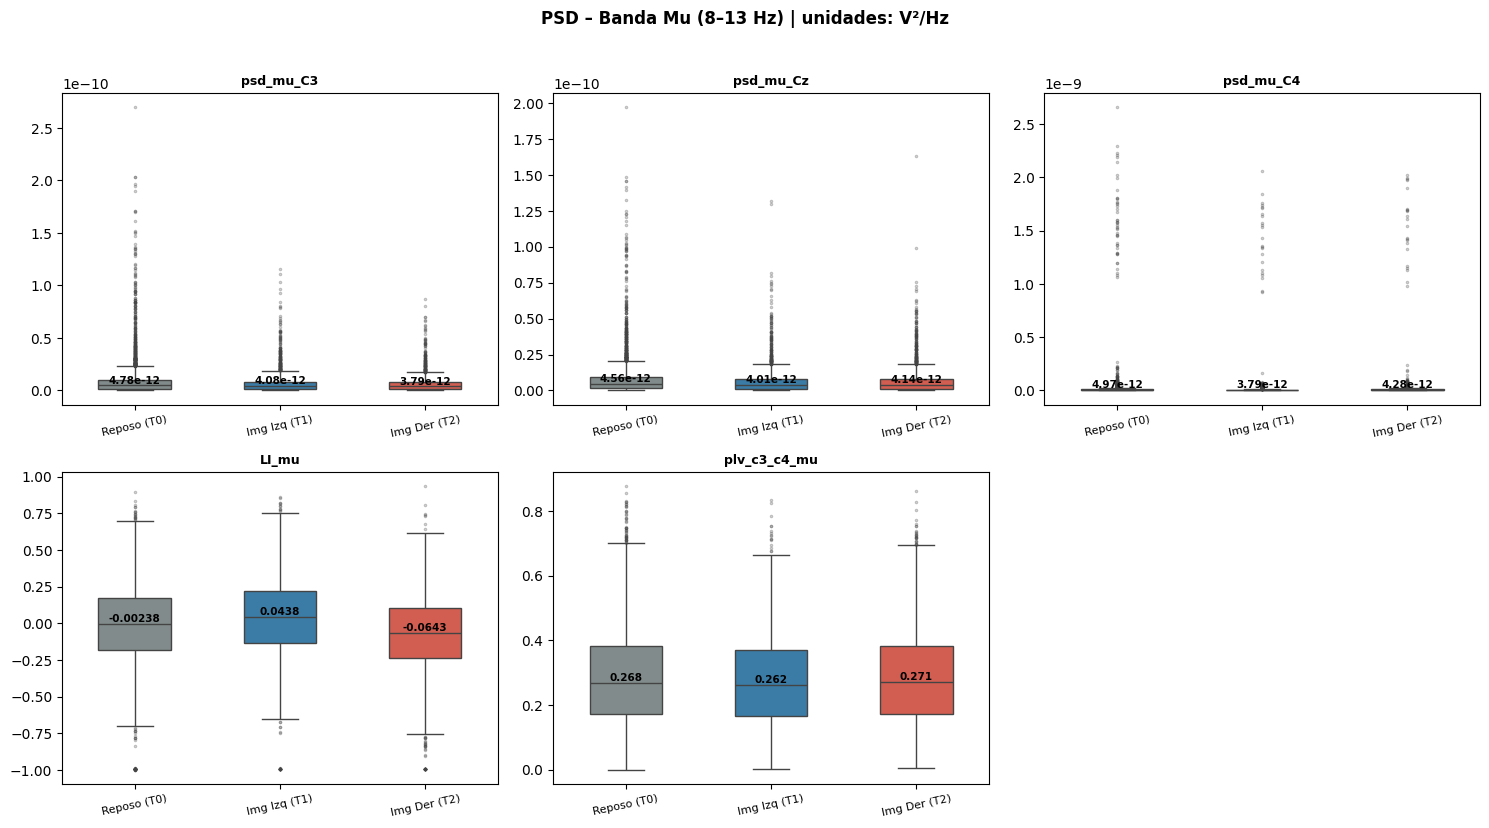

→ Figura guardada: figuras_P2/09a_boxplot_psd_mu.png


In [40]:
feats_mu = [c for c in cols_feat if 'mu' in c.lower()]
boxplot_grupo(
    feats_mu,
    'PSD – Banda Mu (8–13 Hz) | unidades: V²/Hz',
    '09a_boxplot_psd_mu.png',
    df_plot, orden, paleta
)

### **8.2 PSD – Banda Beta (13–30 Hz)**

La Beta complementa la Mu: también desincroniza durante imaginación motora
y su recuperación (Beta rebound) ocurre justo después del movimiento.

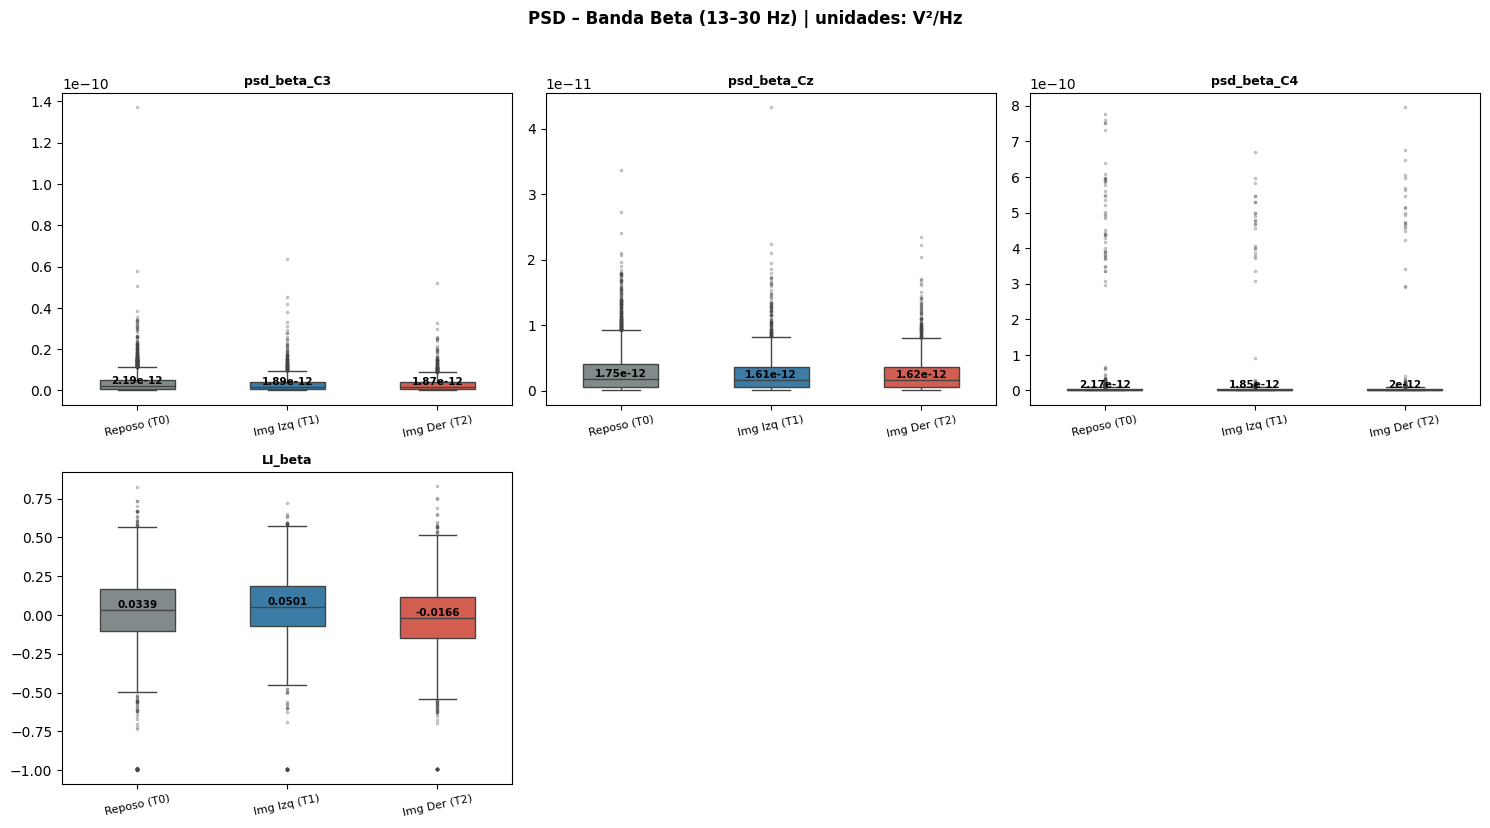

→ Figura guardada: figuras_P2/09b_boxplot_psd_beta.png


In [41]:
feats_beta = [c for c in cols_feat if 'beta' in c.lower()]
boxplot_grupo(
    feats_beta,
    'PSD – Banda Beta (13–30 Hz) | unidades: V²/Hz',
    '09b_boxplot_psd_beta.png',
    df_plot, orden, paleta
)

### **8.3 Parámetros de Hjorth (Actividad y Complejidad)**

Se grafican solo los dos parámetros conservados: **Actividad** y **Complejidad**.
La **Movilidad fue excluida** porque el análisis estadístico (hipótesis 5)
mostró que no discrimina significativamente ninguno de los 3 pares de
condiciones (T1 vs T2, T2 vs T0, T1 vs T0), con η² ≈ 0.0001.
Incluirla en el clasificador solo añadiría ruido sin información útil.

- **Actividad**: varianza de la señal (potencia total en tiempo)
- **Complejidad**: irregularidad espectral a lo largo del tiempo


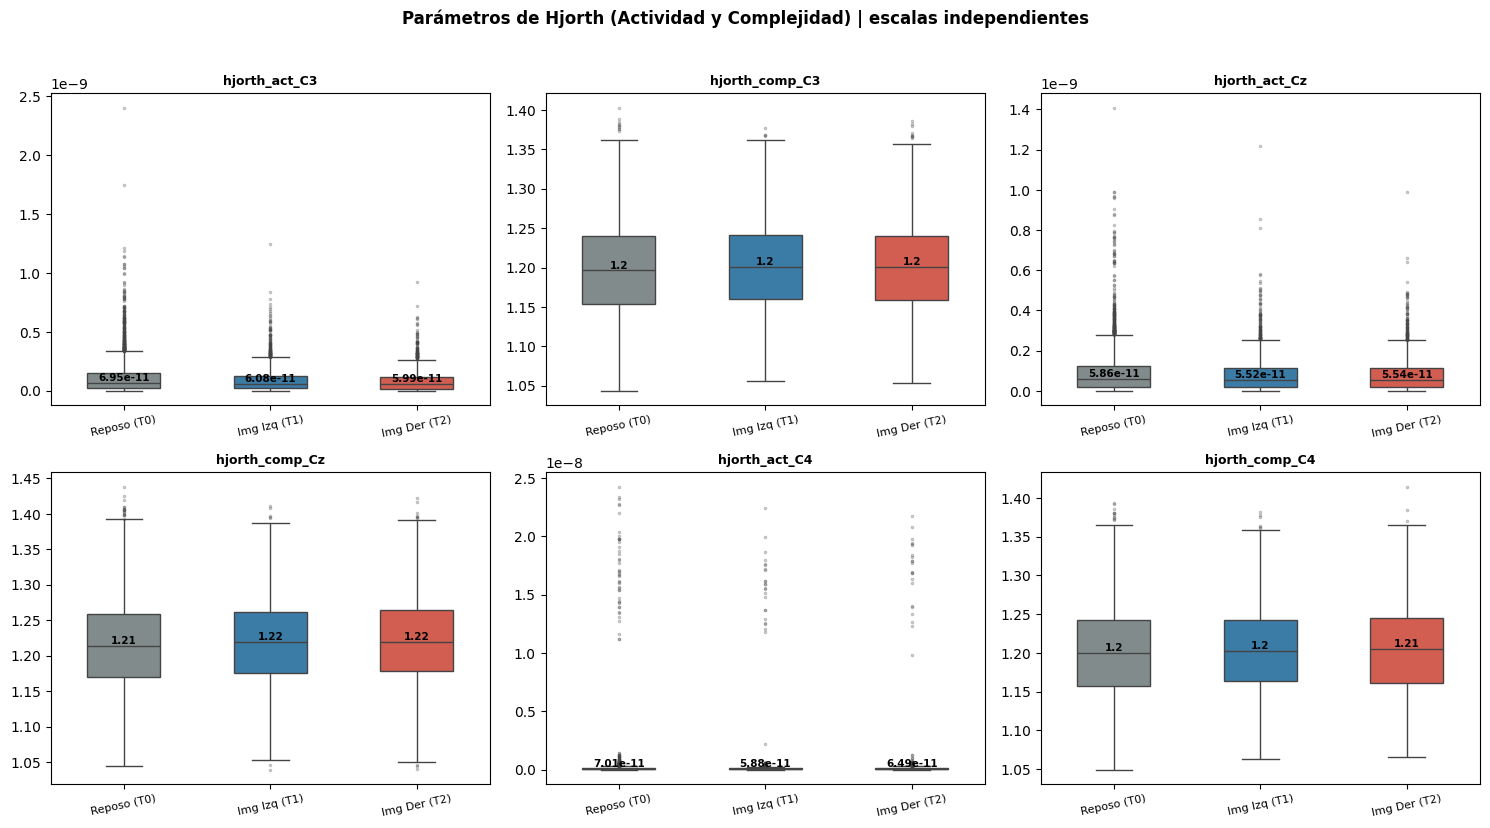

→ Figura guardada: figuras_P2/09c_boxplot_hjorth.png


In [42]:
# Solo graficamos Actividad y Complejidad (Movilidad eliminada)
feats_hjorth = [c for c in cols_feat
                if 'hjorth' in c.lower() and 'mob' not in c.lower()]
boxplot_grupo(
    feats_hjorth,
    'Parámetros de Hjorth (Actividad y Complejidad) | escalas independientes',
    '09c_boxplot_hjorth.png',
    df_plot, orden, paleta
)


### **8.4 Sample Entropy (entropía muestral)**

La SampEn mide la irregularidad de la señal (en nats).
En reposo la señal es más regular (ritmo Mu sincronizado → SampEn baja).
Durante imaginación motora el ritmo se desincroniza → SampEn sube.

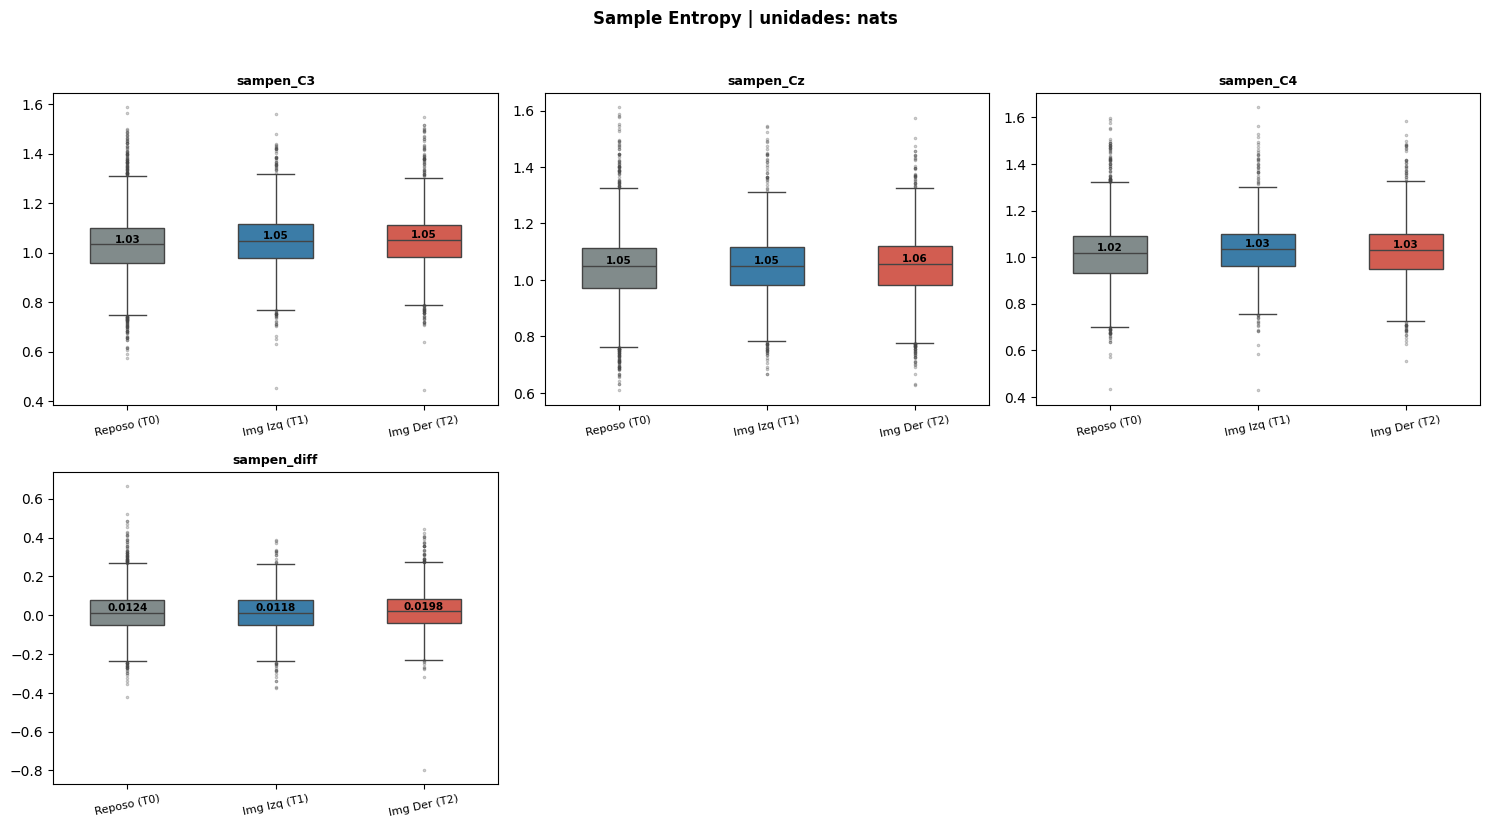

→ Figura guardada: figuras_P2/09d_boxplot_sampen.png


In [43]:
feats_se = [c for c in cols_feat if 'sampen' in c.lower() or 'entropy' in c.lower()]
boxplot_grupo(
    feats_se,
    'Sample Entropy | unidades: nats',
    '09d_boxplot_sampen.png',
    df_plot, orden, paleta
)

### **8.5 Phase Locking Value (PLV) entre C3 y C4**

El PLV mide la sincronía de fase entre los dos hemisferios.
Va de 0 (no sincronizados) a 1 (perfectamente sincronizados).
Durante imaginación unilateral se espera menor PLV porque el hemisferio
contralateral se desacopla del ipsilateral.

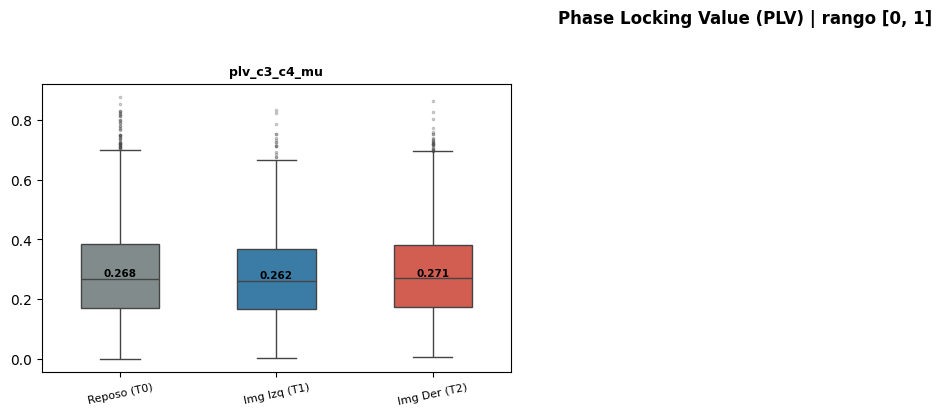

→ Figura guardada: figuras_P2/09e_boxplot_plv.png


In [44]:
feats_plv = [c for c in cols_feat if 'plv' in c.lower()]
boxplot_grupo(
    feats_plv,
    'Phase Locking Value (PLV) | rango [0, 1]',
    '09e_boxplot_plv.png',
    df_plot, orden, paleta
)

### **8.6 Índice de Lateralidad (LI) en bandas Mu y Beta**

El LI cuantifica la **asimetría interhemisférica** de la potencia espectral
entre C3 (hemisferio izquierdo) y C4 (hemisferio derecho).
Va de −1 (dominio total de C4) a +1 (dominio total de C3),
con 0 indicando simetría perfecta entre hemisferios.

$$LI = \frac{PSD_{C3} - PSD_{C4}}{PSD_{C3} + PSD_{C4}}$$

- **LI > 0:** C3 tiene más potencia que C4 → el hemisferio izquierdo domina.
  Se espera durante imaginación de mano **izquierda (T1)**, donde C4 se
  desincroniza (ERD) y su potencia cae, haciendo que C3 quede relativamente mayor.
- **LI < 0:** C4 tiene más potencia que C3 → el hemisferio derecho domina.
  Se espera durante imaginación de mano **derecha (T2)**, donde C3 se
  desincroniza contralateralmente y su potencia cae.
- **LI ≈ 0:** ambos hemisferios tienen potencia similar → simetría bilateral.
  Característico del estado de **reposo (T0)**, donde el ritmo Mu
  se mantiene sincronizado en ambos lados.

A diferencia de usar PSD_C3 y PSD_C4 por separado, el LI **captura
directamente la asimetría** que distingue T1 de T2, que es justamente
la información que un clasificador de lateralidad necesita.
Se calcula tanto en banda **Mu (8–13 Hz)** como en **Beta (13–30 Hz)**
para aprovechar la ERD en ambas bandas sensoriomotoras.

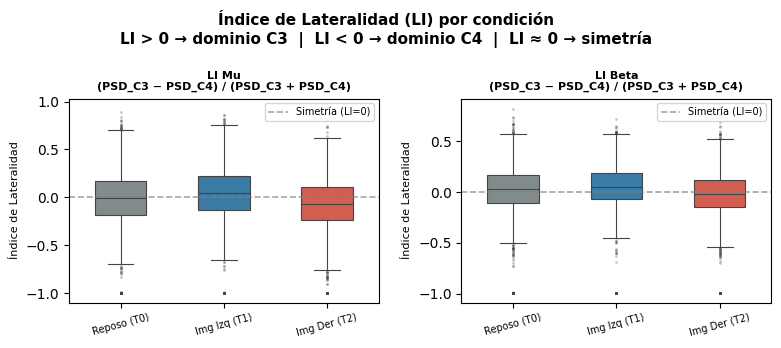

In [45]:
# ── Boxplots — Índice de Lateralidad (LI_mu y LI_beta) ──────────
feats_li = ['LI_mu', 'LI_beta']
feats_li_ok = [f for f in feats_li if f in df_plot.columns]

fig, axes = plt.subplots(1, len(feats_li_ok),
                         figsize=(len(feats_li_ok) * 4, 3.5))
axes = np.array(axes).flatten()   # funciona igual con 1 o 2 subplots

paleta = [COLORES_CLASE[0], COLORES_CLASE[1], COLORES_CLASE[2]]
orden  = [NOMBRES_CLASE[0], NOMBRES_CLASE[1], NOMBRES_CLASE[2]]

titulos_li = {
    'LI_mu'  : 'LI Mu\n(PSD_C3 − PSD_C4) / (PSD_C3 + PSD_C4)',
    'LI_beta': 'LI Beta\n(PSD_C3 − PSD_C4) / (PSD_C3 + PSD_C4)',
}

for i, feat in enumerate(feats_li_ok):
    sns.boxplot(
        data=df_plot, x='condicion', y=feat,
        order=orden, palette=paleta,
        ax=axes[i], width=0.5, linewidth=0.8,
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    # Línea de simetría: LI=0 significa C3==C4
    axes[i].axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7,
                    label='Simetría (LI=0)')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].set_title(titulos_li[feat], fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Índice de Lateralidad', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7, rotation=15)

fig.suptitle('Índice de Lateralidad (LI) por condición\n'
             'LI > 0 → dominio C3  |  LI < 0 → dominio C4  |  LI ≈ 0 → simetría',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras_P2/02b_boxplots_LI.png')


## **9. Pruebas de hipótesis estadísticas**




Para decidir qué características usar en los modelos, seguimos dos pasos:

**Paso A. Análisis detallados de las hipótesis del proyecto 1 (corrección con todos los sijetos) e hipótesis de clasificación**

Para las 4 comparaciones de interés neurofisiológico del proyecto 1 hacemos el flujo habitual:
1. Verificar normalidad con Shapiro-Wilk (o KS si N > 5000).
2. Si normal → t de Student | Si no normal → Mann-Whitney U.
3. Interpretar: p < 0.05 rechaza H₀.

**Paso B.Test global: Kruskal-Wallis sobre todas las características**
Aplicamos Kruskal-Wallis a las 19 características comparando los 3 grupos (T0, T1, T2).
- Es la versión no paramétrica del ANOVA → no asume normalidad.
- Si p < 0.05 → hay al menos un grupo diferente → la característica es útil para clasificar.
- Calculamos también el tamaño del efecto η² (eta cuadrado) para saber cuánto diferencia cada característica.
- Solo las características significativas entrarán a los modelos (requerimiento del proyecto).



#### **Paso A**
#### **1.Análisis detallados de las hipótesis del proyecto 1**

####  Análisis 1. PSD Mu en C3: Imaginación Izquierda (T1) vs Imaginación Derecha (T2)

**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre el movimiento imaginario derecho e izquierdo en C3.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre el movimiento imaginario derecho e izquierdo en C3.


ANÁLISIS 1 — PSD Mu en C3: T1 (Izq) vs T2 (Der)
Shapiro T1 → p = 0.0000 | Shapiro T2 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 3105135.0000
p-value        : 0.031283
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


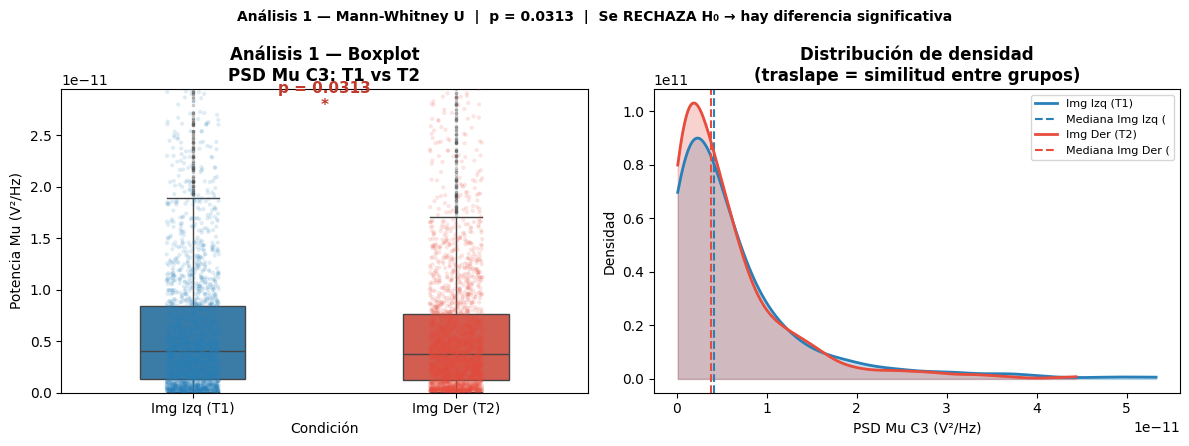

In [46]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import matplotlib.patches as mpatches

# Extraer los grupos de interés
mu_T1_C3 = df_features.loc[df_features['tarea'] == 1, 'psd_mu_C3'].dropna().values
mu_T2_C3 = df_features.loc[df_features['tarea'] == 2, 'psd_mu_C3'].dropna().values

# ── Paso 1: normalidad ───────────────────────────────────────────
# Con N > 5000 Shapiro-Wilk pierde sentido (detecta cualquier
# desviación ínfima como significativa). Usamos KS en ese caso.
from scipy.stats import kstest

def test_normalidad(grupo):
    if len(grupo) <= 5000:
        _, p = shapiro(grupo)
    else:
        _, p = kstest(grupo, 'norm', args=(grupo.mean(), grupo.std()))
    return p

p_norm_t1 = test_normalidad(mu_T1_C3)
p_norm_t2 = test_normalidad(mu_T2_C3)
normal = (p_norm_t1 > 0.05) and (p_norm_t2 > 0.05)

# ── Paso 2: prueba estadística ───────────────────────────────────
if normal:
    stat, p_val = ttest_ind(mu_T1_C3, mu_T2_C3)
    prueba_nombre = 't de Student'
else:
    stat, p_val = mannwhitneyu(mu_T1_C3, mu_T2_C3, alternative='two-sided')
    prueba_nombre = 'Mann-Whitney U'

# ── Paso 3: resultado ────────────────────────────────────────────
decision = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

print('='*60)
print('ANÁLISIS 1 — PSD Mu en C3: T1 (Izq) vs T2 (Der)')
print('='*60)
print(f'Shapiro T1 → p = {p_norm_t1:.4f} | Shapiro T2 → p = {p_norm_t2:.4f}')
print(f'Prueba elegida : {prueba_nombre}')
print(f'Estadístico    : {stat:.4f}')
print(f'p-value        : {p_val:.6f}')
print(f'Conclusión     : {decision}')

# ── Gráfico de interpretación ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Boxplot
datos_bp = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T1_C3, mu_T2_C3]),
    'Condición': ['Img Izq (T1)']*len(mu_T1_C3) + ['Img Der (T2)']*len(mu_T2_C3)
})
sns.boxplot(data=datos_bp, x='Condición', y='PSD Mu C3',
            palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
sns.stripplot(data=datos_bp, x='Condición', y='PSD Mu C3',
              palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
              ax=axes[0], alpha=0.15, size=3, jitter=True)
y_max = datos_bp['PSD Mu C3'].quantile(0.95)
axes[0].set_ylim(bottom=0, top=y_max * 1.25)
axes[0].annotate(f'p = {p_val:.4f}\n{"*" if p_val<0.05 else "ns"}',
                 xy=(0.5, 0.93), xycoords='axes fraction',
                 ha='center', fontsize=11,
                 color='#c0392b' if p_val < 0.05 else '#7f8c8d',
                 fontweight='bold')
axes[0].set_title('Análisis 1 — Boxplot\nPSD Mu C3: T1 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribución de densidad
from scipy.stats import gaussian_kde
for datos, label, color in [
        (mu_T1_C3, 'Img Izq (T1)', COLORES_CLASE[1]),
        (mu_T2_C3, 'Img Der (T2)', COLORES_CLASE[2])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5,
                    label=f'Mediana {label[:9]}')
axes[1].set_xlabel('PSD Mu C3 (V²/Hz)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de densidad\n(traslape = similitud entre grupos)', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle(f'Análisis 1 — {prueba_nombre}  |  p = {p_val:.4f}  |  {decision}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_01_mu_C3_T1vsT2.png', dpi=150, bbox_inches='tight')
plt.show()



### Análisis 2. PSD Beta en C4: Imaginación Izquierda (T1) vs Imaginación Derecha (T2)

**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Beta entre el movimiento imaginario derecho e izquierdo en C4.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Beta entre el movimiento imaginario derecho e izquierdo en C4.


ANÁLISIS 2 — PSD Beta en C4: T1 (Izq) vs T2 (Der)
Shapiro T1 → p = 0.0000 | Shapiro T2 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 2865237.0000
p-value        : 0.007042
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


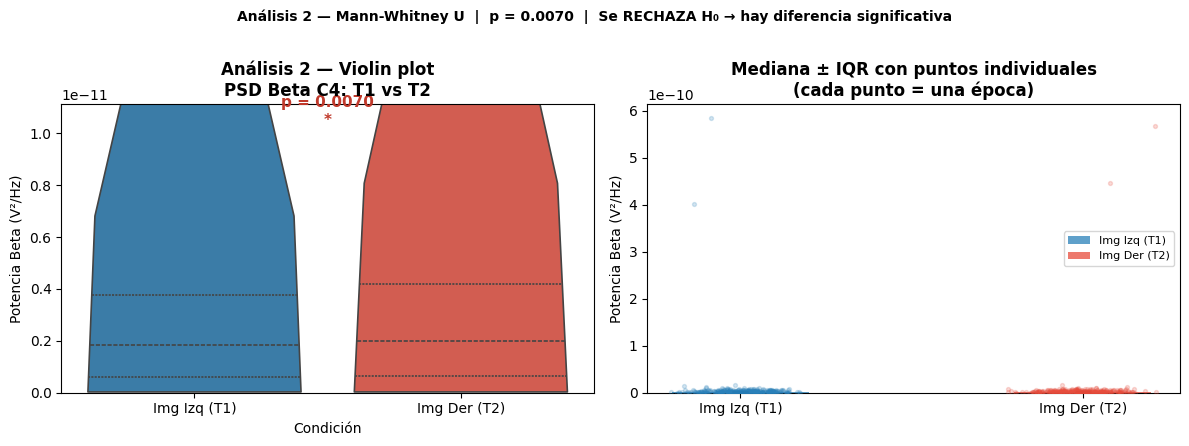

In [47]:
# Extraer grupos
beta_T1_C4 = df_features.loc[df_features['tarea'] == 1, 'psd_beta_C4'].dropna().values
beta_T2_C4 = df_features.loc[df_features['tarea'] == 2, 'psd_beta_C4'].dropna().values

# ── Normalidad ───────────────────────────────────────────────────
p_n1 = test_normalidad(beta_T1_C4)
p_n2 = test_normalidad(beta_T2_C4)
normal2  = (p_n1 > 0.05) and (p_n2 > 0.05)

# ── Prueba ───────────────────────────────────────────────────────
if normal2:
    stat2, p_val2 = ttest_ind(beta_T1_C4, beta_T2_C4)
    prueba2 = 't de Student'
else:
    stat2, p_val2 = mannwhitneyu(beta_T1_C4, beta_T2_C4, alternative='two-sided')
    prueba2 = 'Mann-Whitney U'

decision2 = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val2 < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

print('='*60)
print('ANÁLISIS 2 — PSD Beta en C4: T1 (Izq) vs T2 (Der)')
print('='*60)
print(f'Shapiro T1 → p = {p_n1:.4f} | Shapiro T2 → p = {p_n2:.4f}')
print(f'Prueba elegida : {prueba2}')
print(f'Estadístico    : {stat2:.4f}')
print(f'p-value        : {p_val2:.6f}')
print(f'Conclusión     : {decision2}')

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Boxplot + violin
datos_bp2 = pd.DataFrame({
    'PSD Beta C4': np.concatenate([beta_T1_C4, beta_T2_C4]),
    'Condición': ['Img Izq (T1)']*len(beta_T1_C4) + ['Img Der (T2)']*len(beta_T2_C4)
})
sns.violinplot(data=datos_bp2, x='Condición', y='PSD Beta C4',
               palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
               ax=axes[0], inner='quartile', cut=0, linewidth=1.2)
y_max2 = datos_bp2['PSD Beta C4'].quantile(0.95)
axes[0].set_ylim(bottom=0, top=y_max2 * 1.25)
axes[0].annotate(f'p = {p_val2:.4f}\n{"*" if p_val2<0.05 else "ns"}',
                 xy=(0.5, 0.93), xycoords='axes fraction',
                 ha='center', fontsize=11,
                 color='#c0392b' if p_val2 < 0.05 else '#7f8c8d',
                 fontweight='bold')
axes[0].set_title('Análisis 2 — Violin plot\nPSD Beta C4: T1 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Beta (V²/Hz)')

# Panel B: Barras de media ± std con puntos individuales
grupos_plot = [beta_T1_C4, beta_T2_C4]
labels_plot = ['Img Izq (T1)', 'Img Der (T2)']
colores_plot = [COLORES_CLASE[1], COLORES_CLASE[2]]
medias = [np.median(g) for g in grupos_plot]
q25    = [np.percentile(g, 25) for g in grupos_plot]
q75    = [np.percentile(g, 75) for g in grupos_plot]

for j, (g, lab, col, med, q2, q7) in enumerate(
        zip(grupos_plot, labels_plot, colores_plot, medias, q25, q75)):
    axes[1].bar(j, med, color=col, alpha=0.75, width=0.4, label=lab)
    axes[1].errorbar(j, med, yerr=[[med-q2], [q7-med]],
                     fmt='none', color='black', capsize=6, lw=2)
    # Puntos individuales (muestra)
    n_pts = min(300, len(g))
    idx_s = np.random.choice(len(g), n_pts, replace=False)
    axes[1].scatter(np.random.normal(j, 0.08, n_pts), g[idx_s],
                    color=col, alpha=0.2, s=8, zorder=3)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels_plot)
axes[1].set_ylabel('Potencia Beta (V²/Hz)')
axes[1].set_title('Mediana ± IQR con puntos individuales\n(cada punto = una época)', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle(f'Análisis 2 — {prueba2}  |  p = {p_val2:.4f}  |  {decision2}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_02_beta_C4_T1vsT2.png', dpi=150, bbox_inches='tight')
plt.show()



### **Análisis 3a.** PSD Mu en C3: Imaginación Derecha (T2) vs Reposo (T0)


**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano derecha en C3 y
el estado de reposo.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano derecha en C3 y
el estado de reposo.


ANÁLISIS 3a — PSD Mu en C3: T2 (Img Der) vs T0 (Reposo)
Shapiro T2 → p = 0.0000 | Shapiro T0 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 5281001.0000
p-value        : 0.000000
Dirección ERD  : T2 < T0 (ERD confirmado ✓)
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


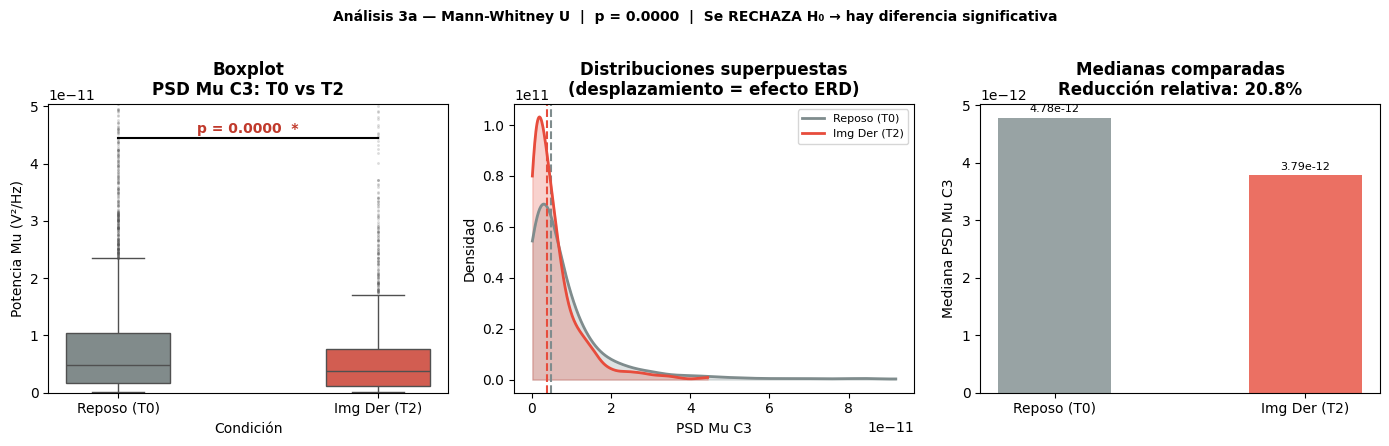

In [48]:
# Grupos: T2 (imaginación derecha) vs T0 (reposo) — PSD Mu en C3
mu_T2_C3 = df_features.loc[df_features['tarea'] == 2, 'psd_mu_C3'].dropna().values
mu_T0_C3 = df_features.loc[df_features['tarea'] == 0, 'psd_mu_C3'].dropna().values

# ── Normalidad ───────────────────────────────────────────────────
p_n_t2 = test_normalidad(mu_T2_C3)
p_n_t0 = test_normalidad(mu_T0_C3)
normal3a  = (p_n_t2 > 0.05) and (p_n_t0 > 0.05)

# ── Prueba ───────────────────────────────────────────────────────
if normal3a:
    stat3a, p_val3a = ttest_ind(mu_T2_C3, mu_T0_C3)
    prueba3a = 't de Student'
else:
    stat3a, p_val3a = mannwhitneyu(mu_T2_C3, mu_T0_C3, alternative='two-sided')
    prueba3a = 'Mann-Whitney U'

decision3a = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val3a < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

# Dirección del efecto (esperamos T2 < T0 por ERD)
dir_efecto = 'T2 < T0 (ERD confirmado ✓)' if np.median(mu_T2_C3) < np.median(mu_T0_C3) else 'T2 ≥ T0 (ERD no observado)'

print('='*60)
print('ANÁLISIS 3a — PSD Mu en C3: T2 (Img Der) vs T0 (Reposo)')
print('='*60)
print(f'Shapiro T2 → p = {p_n_t2:.4f} | Shapiro T0 → p = {p_n_t0:.4f}')
print(f'Prueba elegida : {prueba3a}')
print(f'Estadístico    : {stat3a:.4f}')
print(f'p-value        : {p_val3a:.6f}')
print(f'Dirección ERD  : {dir_efecto}')
print(f'Conclusión     : {decision3a}')

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel A: Boxplot comparativo
datos_3a = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T0_C3, mu_T2_C3]),
    'Condición': ['Reposo (T0)']*len(mu_T0_C3) + ['Img Der (T2)']*len(mu_T2_C3)
})
sns.boxplot(data=datos_3a, x='Condición', y='PSD Mu C3',
            order=['Reposo (T0)', 'Img Der (T2)'],
            palette=[COLORES_CLASE[0], COLORES_CLASE[2]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
y_lim3a = datos_3a['PSD Mu C3'].quantile(0.97)
axes[0].set_ylim(0, y_lim3a * 1.25)
# Línea de comparación con p-value
y_bar = y_lim3a * 1.10
axes[0].plot([0, 1], [y_bar, y_bar], 'k-', lw=1.5)
axes[0].text(0.5, y_bar * 1.02,
             f'p = {p_val3a:.4f}  {"*" if p_val3a<0.05 else "ns"}',
             ha='center', fontsize=10,
             color='#c0392b' if p_val3a < 0.05 else '#7f8c8d', fontweight='bold')
axes[0].set_title('Boxplot\nPSD Mu C3: T0 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribuciones superpuestas
for datos, label, color in [
        (mu_T0_C3, 'Reposo (T0)', COLORES_CLASE[0]),
        (mu_T2_C3, 'Img Der (T2)', COLORES_CLASE[2])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5)
axes[1].set_xlabel('PSD Mu C3')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuciones superpuestas\n(desplazamiento = efecto ERD)', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel C: Medianas con reducción relativa
med_t0 = np.median(mu_T0_C3)
med_t2 = np.median(mu_T2_C3)
reduccion = (med_t0 - med_t2) / med_t0 * 100
barras = axes[2].bar(['Reposo (T0)', 'Img Der (T2)'],
                     [med_t0, med_t2],
                     color=[COLORES_CLASE[0], COLORES_CLASE[2]],
                     alpha=0.8, width=0.45)
for bar, val in zip(barras, [med_t0, med_t2]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{val:.2e}', ha='center', fontsize=8)
axes[2].set_ylabel('Mediana PSD Mu C3')
axes[2].set_title(f'Medianas comparadas\nReducción relativa: {reduccion:.1f}%', fontweight='bold')

fig.suptitle(f'Análisis 3a — {prueba3a}  |  p = {p_val3a:.4f}  |  {decision3a}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_03a_mu_C3_T2vsT0.png', dpi=150, bbox_inches='tight')
plt.show()



### **Análisis 3b.** PSD Mu en C3: Imaginación Izquierda (T1) vs Reposo (T0)


**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano izquierda en C3 y
el estado de reposo.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano izquierda en C3 y
el estado de reposo.


ANÁLISIS 3b — PSD Mu en C3: T1 (Img Izq) vs T0 (Reposo)
Shapiro T1 → p = 0.0000 | Shapiro T0 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 5589783.0000
p-value        : 0.000000
Dirección ERD  : T1 < T0 (ERD en C3 ipsilateral)
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


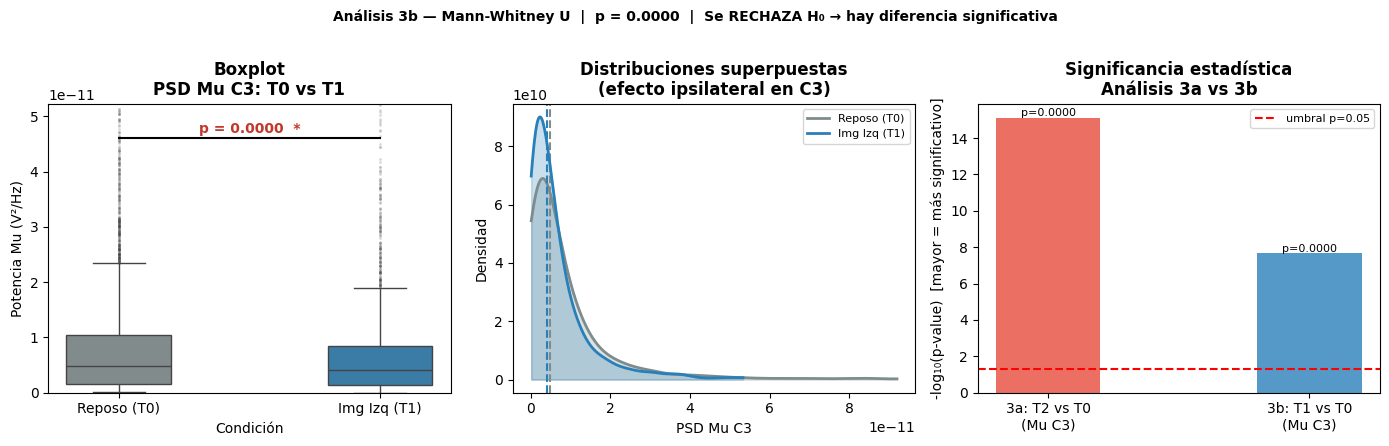

In [49]:
# Grupos: T1 (imaginación izquierda) vs T0 (reposo) — PSD Mu en C3
# mu_T1_C3 ya está calculado en Análisis 1
# mu_T0_C3 ya está calculado en Análisis 3a

# -- Normalidad ---------------------------------------------------
p_n_t1_3b = test_normalidad(mu_T1_C3)
p_n_t0_3b = test_normalidad(mu_T0_C3)
normal3b      = (p_n_t1_3b > 0.05) and (p_n_t0_3b > 0.05)

# -- Prueba -------------------------------------------------------
if normal3b:
    stat3b, p_val3b = ttest_ind(mu_T1_C3, mu_T0_C3)
    prueba3b = 't de Student'
else:
    stat3b, p_val3b = mannwhitneyu(mu_T1_C3, mu_T0_C3, alternative='two-sided')
    prueba3b = 'Mann-Whitney U'

decision3b = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val3b < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'
dir_efecto3b = 'T1 < T0 (ERD en C3 ipsilateral)' if np.median(mu_T1_C3) < np.median(mu_T0_C3) else 'T1 ≥ T0 (sin ERD en C3 ipsilateral)'

print('='*60)
print('ANÁLISIS 3b — PSD Mu en C3: T1 (Img Izq) vs T0 (Reposo)')
print('='*60)
print(f'Shapiro T1 → p = {p_n_t1_3b:.4f} | Shapiro T0 → p = {p_n_t0_3b:.4f}')
print(f'Prueba elegida : {prueba3b}')
print(f'Estadístico    : {stat3b:.4f}')
print(f'p-value        : {p_val3b:.6f}')
print(f'Dirección ERD  : {dir_efecto3b}')
print(f'Conclusión     : {decision3b}')

# -- Gráfico ------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel A: Boxplot
datos_3b = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T0_C3, mu_T1_C3]),
    'Condición': ['Reposo (T0)']*len(mu_T0_C3) + ['Img Izq (T1)']*len(mu_T1_C3)
})
sns.boxplot(data=datos_3b, x='Condición', y='PSD Mu C3',
            order=['Reposo (T0)', 'Img Izq (T1)'],
            palette=[COLORES_CLASE[0], COLORES_CLASE[1]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
y_lim3b = datos_3b['PSD Mu C3'].quantile(0.97)
axes[0].set_ylim(0, y_lim3b * 1.25)
y_bar3b = y_lim3b * 1.10
axes[0].plot([0, 1], [y_bar3b, y_bar3b], 'k-', lw=1.5)
axes[0].text(0.5, y_bar3b * 1.02,
             f'p = {p_val3b:.4f}  {"*" if p_val3b<0.05 else "ns"}',
             ha='center', fontsize=10,
             color='#c0392b' if p_val3b < 0.05 else '#7f8c8d', fontweight='bold')
axes[0].set_title('Boxplot\nPSD Mu C3: T0 vs T1', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribuciones superpuestas
for datos, label, color in [
        (mu_T0_C3, 'Reposo (T0)', COLORES_CLASE[0]),
        (mu_T1_C3, 'Img Izq (T1)', COLORES_CLASE[1])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5)
axes[1].set_xlabel('PSD Mu C3')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuciones superpuestas\n(efecto ipsilateral en C3)', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel C: Comparación directa A1 vs A3a vs A3b (resumen de los 4 análisis)
resumen_labels = ['3a: T2 vs T0\n(Mu C3)', '3b: T1 vs T0\n(Mu C3)']
resumen_pvals  = [p_val3a, p_val3b]
resumen_stats  = [stat3a, stat3b]
barras_res = axes[2].bar(resumen_labels, [-np.log10(p+1e-300) for p in resumen_pvals],
                         color=[COLORES_CLASE[2], COLORES_CLASE[1]], alpha=0.8, width=0.4)
axes[2].axhline(-np.log10(0.05), ls='--', color='red', lw=1.5, label='umbral p=0.05')
axes[2].set_ylabel('-log₁₀(p-value)  [mayor = más significativo]')
axes[2].set_title('Significancia estadística\nAnálisis 3a vs 3b', fontweight='bold')
axes[2].legend(fontsize=8)
for bar, pv in zip(barras_res, resumen_pvals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'p={pv:.4f}', ha='center', fontsize=8)

fig.suptitle(f'Análisis 3b — {prueba3b}  |  p = {p_val3b:.4f}  |  {decision3b}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_03b_mu_C3_T1vsT0.png', dpi=150, bbox_inches='tight')
plt.show()


---
##### Resumen general de los 4 análisis de hipótesis

Esta celda consolida los resultados de los 4 análisis y nos da una vista
rápida de la existencia de diferencias significativas en las fases de interés.


RESUMEN DE HIPÓTESIS
Análisis    Variable   Grupos         Prueba  Estadístico  p-value   Decisión
       1   PSD Mu C3 T1 vs T2 Mann-Whitney U    3105135.0 0.031283 Rechaza H₀
       2 PSD Beta C4 T1 vs T2 Mann-Whitney U    2865237.0 0.007042 Rechaza H₀
      3a   PSD Mu C3 T2 vs T0 Mann-Whitney U    5281001.0 0.000000 Rechaza H₀
      3b   PSD Mu C3 T1 vs T0 Mann-Whitney U    5589783.0 0.000000 Rechaza H₀


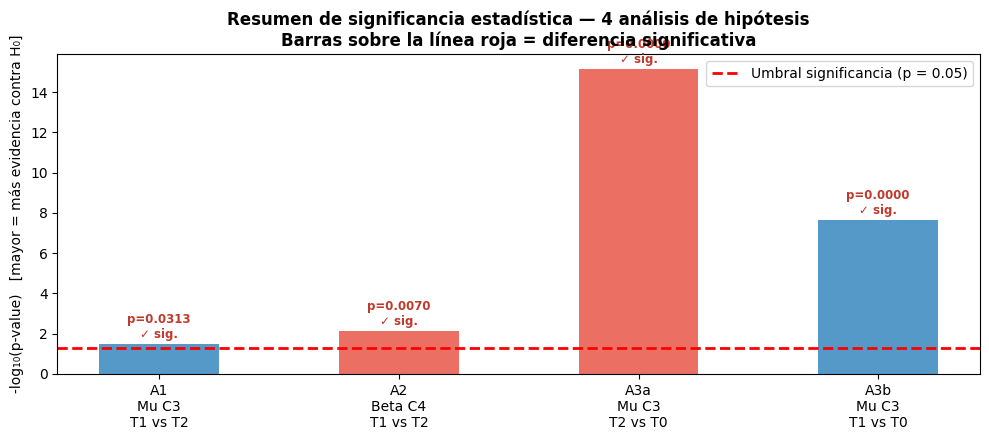

In [50]:
# Tabla resumen
tabla_hipotesis = pd.DataFrame([
    {'Análisis': '1',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T1 vs T2',
     'Prueba': prueba_nombre,
     'Estadístico': round(stat, 4),
     'p-value': round(p_val, 6),
     'Decisión': 'Rechaza H₀' if p_val < 0.05 else 'No rechaza H₀'},
    {'Análisis': '2',
     'Variable': 'PSD Beta C4',
     'Grupos': 'T1 vs T2',
     'Prueba': prueba2,
     'Estadístico': round(stat2, 4),
     'p-value': round(p_val2, 6),
     'Decisión': 'Rechaza H₀' if p_val2 < 0.05 else 'No rechaza H₀'},
    {'Análisis': '3a',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T2 vs T0',
     'Prueba': prueba3a,
     'Estadístico': round(stat3a, 4),
     'p-value': round(p_val3a, 6),
     'Decisión': 'Rechaza H₀' if p_val3a < 0.05 else 'No rechaza H₀'},
    {'Análisis': '3b',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T1 vs T0',
     'Prueba': prueba3b,
     'Estadístico': round(stat3b, 4),
     'p-value': round(p_val3b, 6),
     'Decisión': 'Rechaza H₀' if p_val3b < 0.05 else 'No rechaza H₀'},
])

print('RESUMEN DE HIPÓTESIS')
print('='*80)
print(tabla_hipotesis.to_string(index=False))

# -- Gráfico resumen: -log10(p) de los 4 análisis -----------------
fig, ax = plt.subplots(figsize=(10, 4.5))
etiquetas = [
    'A1\nMu C3\nT1 vs T2',
    'A2\nBeta C4\nT1 vs T2',
    'A3a\nMu C3\nT2 vs T0',
    'A3b\nMu C3\nT1 vs T0'
]
pvals_todos = [p_val, p_val2, p_val3a, p_val3b]
colores_res = [COLORES_CLASE[1], COLORES_CLASE[2], COLORES_CLASE[2], COLORES_CLASE[1]]
log_p = [-np.log10(p + 1e-300) for p in pvals_todos]

bars = ax.bar(etiquetas, log_p, color=colores_res, alpha=0.8, width=0.5)
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=2,
            label='Umbral significancia (p = 0.05)')

for bar, pv in zip(bars, pvals_todos):
    label_p = f'p={pv:.4f}\n{"✓ sig." if pv<0.05 else "ns"}'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            label_p, ha='center', fontsize=8.5,
            color='#c0392b' if pv < 0.05 else '#7f8c8d',
            fontweight='bold')

ax.set_ylabel('-log₁₀(p-value)   [mayor = más evidencia contra H₀]')
ax.set_title('Resumen de significancia estadística — 4 análisis de hipótesis\n'
             'Barras sobre la línea roja = diferencia significativa',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_resumen_4analisis.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### **Paso A**

#### **2. Hipótesis sobre índices nuevos: Hjorth, Sample Entropy, PLV, LI y SampEn_diff**

Estas hipótesis complementan las del Proyecto 1 (PSD) con los índices
nuevos extraídos en este proyecto. El objetivo es demostrar que cada uno
discrimina entre las condiciones y por eso tiene sentido usarlo como
feature en el clasificador.

Para cada par de grupos usamos el mismo flujo:
- **Shapiro-Wilk** (o KS si N > 5000) para verificar normalidad.
- Si normal → **t de Student**; si no → **Mann-Whitney U**.

Al final, un resumen conjunto de todas las hipótesis del proyecto.

> **Cambio respecto a versión anterior:** Hjorth Movilidad fue eliminada
> (0/3 significativa, η²≈0.0001). Se evalúan en su lugar Actividad y Complejidad.
> Se agregan hipótesis 8 (LI_mu), 9 (LI_beta) y 10 (sampen_diff).



### Hipótesis 3. Hjorth Movilidad en C3

La Movilidad de Hjorth captura la frecuencia media de la señal.
Si el ERD modifica la banda Mu durante la imaginación motora,
la frecuencia dominante de C3 debería cambiar entre condiciones.

| Sub-hipótesis | Grupos | Pregunta |
| --- | --- | --- |
| **3a** | T1 vs T2 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **3b** | T2 vs T0 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **c** | T1 vs T0 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |


HIPÓTESIS 5a — Hjorth ACTIVIDAD C3
─────────────────────────────────────────────────────────────────
  H5a | T1 vs T2     | Mann-Whitney U  | p=0.094350 | No rechaza H₀
  H5b | T2 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
  H5c | T1 vs T0     | Mann-Whitney U  | p=0.000001 | Rechaza H₀

HIPÓTESIS 5b — Hjorth COMPLEJIDAD C3
─────────────────────────────────────────────────────────────────
  H5a | T1 vs T2     | Mann-Whitney U  | p=0.760938 | No rechaza H₀
  H5b | T2 vs T0     | Mann-Whitney U  | p=0.043287 | Rechaza H₀
  H5c | T1 vs T0     | Mann-Whitney U  | p=0.020791 | Rechaza H₀


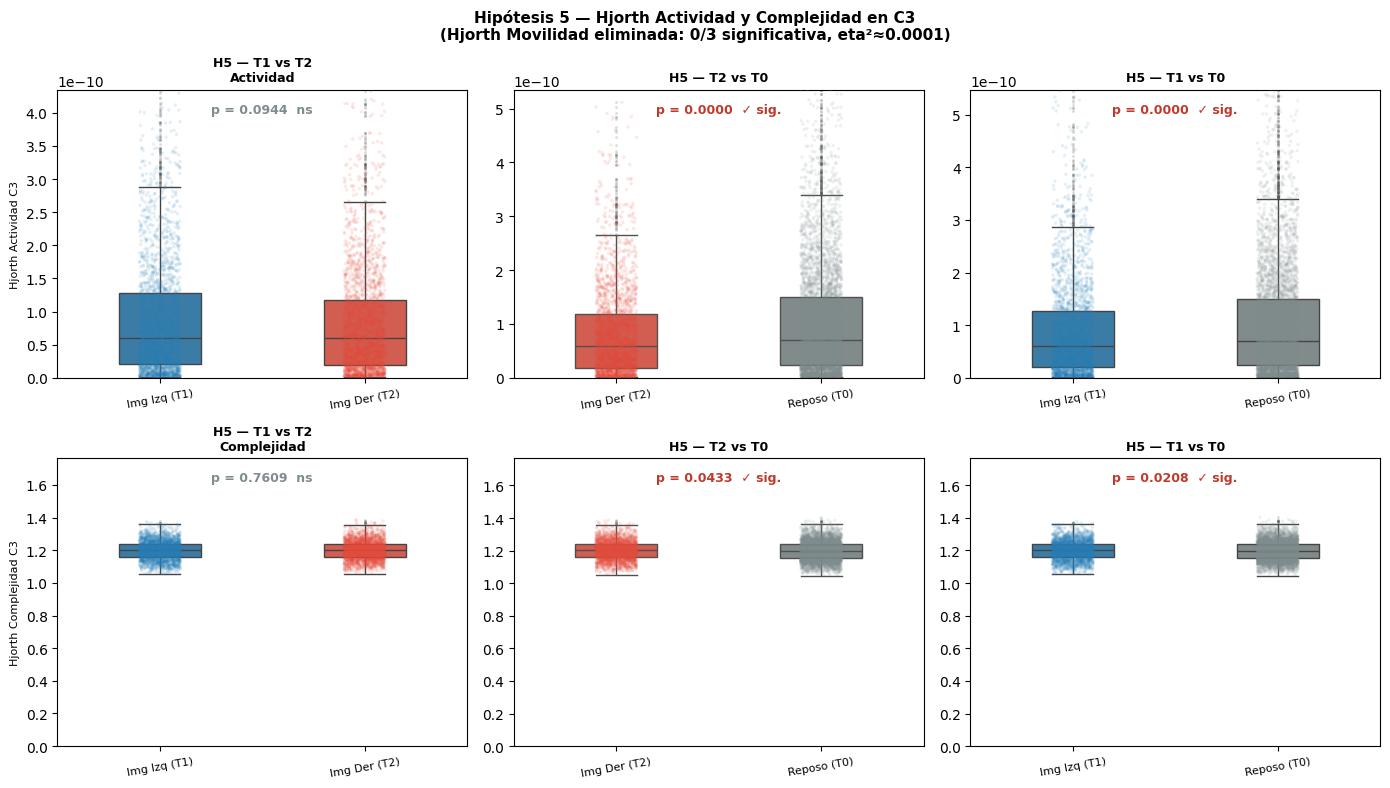

→ Figura guardada: figuras_P2/hipotesis_5_hjorth_act_comp_C3.png


In [51]:
# -- Extraer grupos: Hjorth Actividad C3 -------------------------
act_T0 = df_features.loc[df_features['tarea'] == 0, 'hjorth_act_C3'].dropna().values
act_T1 = df_features.loc[df_features['tarea'] == 1, 'hjorth_act_C3'].dropna().values
act_T2 = df_features.loc[df_features['tarea'] == 2, 'hjorth_act_C3'].dropna().values

# -- Extraer grupos: Hjorth Complejidad C3 ------------------------
comp_T0 = df_features.loc[df_features['tarea'] == 0, 'hjorth_comp_C3'].dropna().values
comp_T1 = df_features.loc[df_features['tarea'] == 1, 'hjorth_comp_C3'].dropna().values
comp_T2 = df_features.loc[df_features['tarea'] == 2, 'hjorth_comp_C3'].dropna().values

# -- Función reutilizable (se define aquí si no existe aún) --------
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, kstest

def prueba_dos_grupos(g1, g2, nombre1, nombre2, variable, analisis_id):
    """Shapiro/KS → t-Student o Mann-Whitney. Devuelve dict."""
    def test_norm(g):
        if len(g) <= 5000:
            _, p = shapiro(g)
        else:
            _, p = kstest((g - g.mean()) / g.std(), 'norm')
        return p

    p_n1 = test_norm(g1)
    p_n2 = test_norm(g2)
    normal = (p_n1 > 0.05) and (p_n2 > 0.05)

    if normal:
        stat, p_val = ttest_ind(g1, g2)
        prueba = 't de Student'
    else:
        stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
        prueba = 'Mann-Whitney U'

    return {
        'id': analisis_id, 'variable': variable,
        'grupos': f'{nombre1} vs {nombre2}',
        'prueba': prueba, 'stat': round(stat, 4),
        'p_value': round(p_val, 6),
        'decision': 'Rechaza H₀' if p_val < 0.05 else 'No rechaza H₀',
        'p_norm_g1': round(p_n1, 4), 'p_norm_g2': round(p_n2, 4)
    }

# -- H5: Actividad C3 (3 pares) ------------------------------------
res_5a_act = prueba_dos_grupos(act_T1, act_T2, 'T1', 'T2', 'Hjorth Act C3', '5a')
res_5b_act = prueba_dos_grupos(act_T2, act_T0, 'T2', 'T0', 'Hjorth Act C3', '5b')
res_5c_act = prueba_dos_grupos(act_T1, act_T0, 'T1', 'T0', 'Hjorth Act C3', '5c')

# -- H5: Complejidad C3 (3 pares) ----------------------------------
res_5a_comp = prueba_dos_grupos(comp_T1, comp_T2, 'T1', 'T2', 'Hjorth Comp C3', '5a')
res_5b_comp = prueba_dos_grupos(comp_T2, comp_T0, 'T2', 'T0', 'Hjorth Comp C3', '5b')
res_5c_comp = prueba_dos_grupos(comp_T1, comp_T0, 'T1', 'T0', 'Hjorth Comp C3', '5c')

# -- Imprimir resultados --------------------------------------------
print('HIPÓTESIS 5a — Hjorth ACTIVIDAD C3')
print('─' * 65)
for r in [res_5a_act, res_5b_act, res_5c_act]:
    print(f"  H{r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

print()
print('HIPÓTESIS 5b — Hjorth COMPLEJIDAD C3')
print('─' * 65)
for r in [res_5a_comp, res_5b_comp, res_5c_comp]:
    print(f"  H{r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# -- Gráfico: 2 filas × 3 columnas --------------------------------
# Fila superior: Actividad | Fila inferior: Complejidad
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

pares_act  = [
    (act_T1,  act_T2,  'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_5a_act,  '5a'),
    (act_T2,  act_T0,  'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_5b_act,  '5b'),
    (act_T1,  act_T0,  'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_5c_act,  '5c'),
]
pares_comp = [
    (comp_T1, comp_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_5a_comp, '5a'),
    (comp_T2, comp_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_5b_comp, '5b'),
    (comp_T1, comp_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_5c_comp, '5c'),
]

for fila, (pares, ylabel_base) in enumerate([(pares_act,  'Hjorth Actividad C3'),
                                              (pares_comp, 'Hjorth Complejidad C3')]):
    for col, (ga, gb, la, lb, ca, cb, res, sid) in enumerate(pares):
        ax = axes[fila, col]
        label_map = {'T0': NOMBRES_CLASE[0], 'T1': NOMBRES_CLASE[1], 'T2': NOMBRES_CLASE[2]}
        df_bp = pd.DataFrame({
            ylabel_base: np.concatenate([ga, gb]),
            'Condición' : [label_map[la]] * len(ga) + [label_map[lb]] * len(gb)
        })
        sns.boxplot(data=df_bp, x='Condición', y=ylabel_base,
                    palette=[ca, cb], ax=ax, width=0.4,
                    flierprops=dict(marker='.', markersize=2, alpha=0.2))
        sns.stripplot(data=df_bp, x='Condición', y=ylabel_base,
                      palette=[ca, cb], ax=ax,
                      alpha=0.12, size=2.5, jitter=True)

        # Límite y p-value
        ylim = df_bp[ylabel_base].quantile(0.97)
        ax.set_ylim(0, ylim * 1.35)
        pv = res['p_value']
        ax.annotate(f"p = {pv:.4f}  {'✓ sig.' if pv < 0.05 else 'ns'}",
                    xy=(0.5, 0.92), xycoords='axes fraction', ha='center',
                    fontsize=9, fontweight='bold',
                    color='#c0392b' if pv < 0.05 else '#7f8c8d')

        if col == 0:
            ax.set_ylabel(ylabel_base, fontsize=8)
        else:
            ax.set_ylabel('')
        ax.set_title(f'H5 — {la} vs {lb}', fontweight='bold', fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=8, rotation=10)

axes[0, 0].set_title('H5 — T1 vs T2\nActividad', fontweight='bold', fontsize=9)
axes[1, 0].set_title('H5 — T1 vs T2\nComplejidad', fontweight='bold', fontsize=9)

fig.suptitle('Hipótesis 5 — Hjorth Actividad y Complejidad en C3\n'
             '(Hjorth Movilidad eliminada: 0/3 significativa, eta²≈0.0001)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_5_hjorth_act_comp_C3.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura guardada: figuras_P2/hipotesis_5_hjorth_act_comp_C3.png')

# Guardar resultados para usar en la tabla resumen
res_5a = res_5a_act    # alias para compatibilidad con celda de resumen
res_5b = res_5b_act
res_5c = res_5c_act
res_5a_c = res_5a_comp  # complejidad disponible también
res_5b_c = res_5b_comp
res_5c_c = res_5c_comp

---
### **Hipótesis 5. Sample Entropy en C3**

La Sample Entropy mide la irregularidad de la señal.
En reposo domina el ritmo Mu regular → señal predecible → SampEn baja.
Durante imaginación motora la señal se desincroniza → más caótica → SampEn mayor.
Si esto ocurre de forma diferente según la lateralidad, SampEn discrimina las 3 clases.

| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **5a** | T1 vs T2 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **5b** | T2 vs T0 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **5c** | T1 vs T0 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

H 6a | T1 vs T2     | Mann-Whitney U  | p=0.665582 | No rechaza H₀
H 6b | T2 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
H 6c | T1 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀


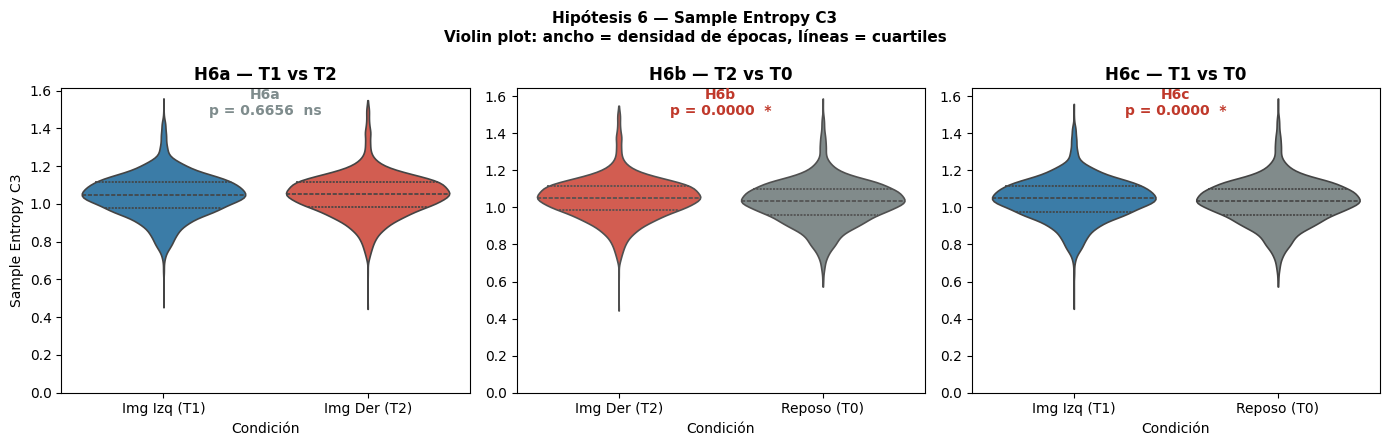

In [52]:
# -- Extraer grupos: Sample Entropy C3 --------------------------
se_T0 = df_features.loc[df_features['tarea'] == 0, 'sampen_C3'].dropna().values
se_T1 = df_features.loc[df_features['tarea'] == 1, 'sampen_C3'].dropna().values
se_T2 = df_features.loc[df_features['tarea'] == 2, 'sampen_C3'].dropna().values

# -- Tres sub-hipótesis -------------------------------------------
res_6a = prueba_dos_grupos(se_T1, se_T2, 'T1', 'T2', 'SampEn C3', '6a')
res_6b = prueba_dos_grupos(se_T2, se_T0, 'T2', 'T0', 'SampEn C3', '6b')
res_6c = prueba_dos_grupos(se_T1, se_T0, 'T1', 'T0', 'SampEn C3', '6c')

for r in [res_6a, res_6b, res_6c]:
    print(f"H {r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# -- Gráfico: distribuciones de densidad superpuestas -------------
# Elegimos violin porque SampEn tiene distribuciones asimétricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares6 = [
    (se_T1, se_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_6a, '6a'),
    (se_T2, se_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_6b, '6b'),
    (se_T1, se_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_6c, '6c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares6):
    df_vp = pd.DataFrame({
        'SampEn C3': np.concatenate([ga, gb]),
        'Condición': [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[la]]]*len(ga) +
                     [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[lb]]]*len(gb)
    })
    sns.violinplot(data=df_vp, x='Condición', y='SampEn C3',
                   palette=[ca, cb], ax=ax, inner='quartile',
                   cut=0, linewidth=1.2)
    pv = res['p_value']
    ylim = df_vp['SampEn C3'].quantile(0.98)
    ax.set_ylim(bottom=0)
    ax.annotate(f"H{sid}\np = {pv:.4f}  {'*' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.91), xycoords='axes fraction', ha='center',
                fontsize=10, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H6{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('Sample Entropy C3' if sid == '6a' else '')

fig.suptitle('Hipótesis 6 — Sample Entropy C3\n'
             'Violin plot: ancho = densidad de épocas, líneas = cuartiles',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_6_sampen_C3.png', dpi=150, bbox_inches='tight')
plt.show()


---
### **Hipótesis 6. Phase Locking Value (banda Mu) entre C3 y C4**

El PLV mide la sincronía de fase entre los dos hemisferios.
En reposo ambos oscilan juntos (PLV alto).
Durante imaginación unilateral un hemisferio se desacopla del otro → PLV baja.
Si el desacoplamiento es diferente según qué mano se imagina,
el PLV puede ayudar a distinguir T1 de T2 además de separarlos del reposo.

| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **6a** | T1 vs T2 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **6b** | T2 vs T0 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **6c** | T1 vs T0 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

H 7a | T1 vs T2     | Mann-Whitney U  | p=0.059037 | No rechaza H₀
H 7b | T2 vs T0     | Mann-Whitney U  | p=0.826711 | No rechaza H₀
H 7c | T1 vs T0     | Mann-Whitney U  | p=0.015921 | Rechaza H₀


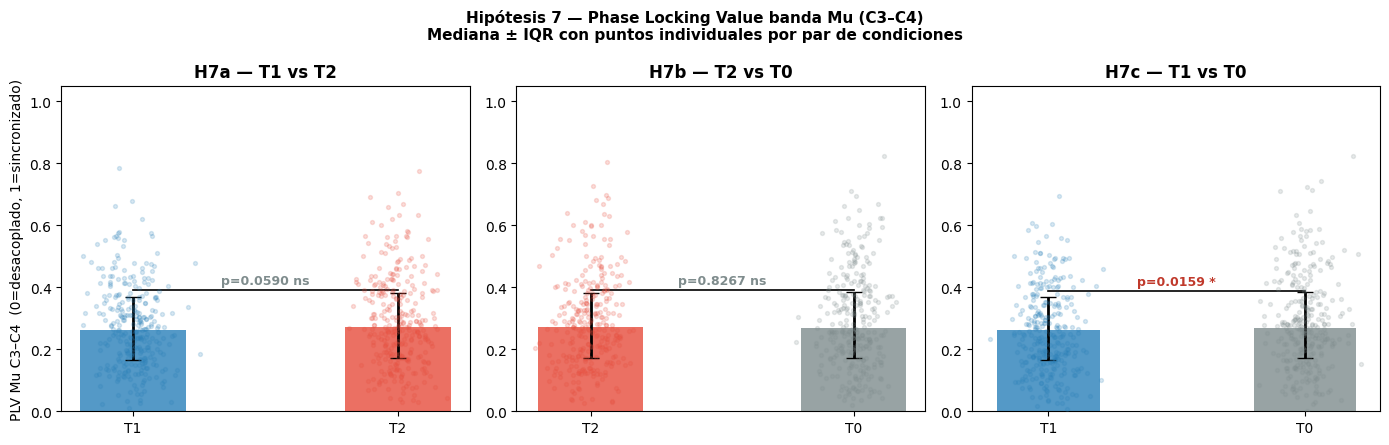

In [53]:
# ── Extraer grupos: PLV Mu C3-C4 ───────────────────────────────
plv_T0 = df_features.loc[df_features['tarea'] == 0, 'plv_c3_c4_mu'].dropna().values
plv_T1 = df_features.loc[df_features['tarea'] == 1, 'plv_c3_c4_mu'].dropna().values
plv_T2 = df_features.loc[df_features['tarea'] == 2, 'plv_c3_c4_mu'].dropna().values

# ── Tres sub-hipótesis ───────────────────────────────────────────
res_7a = prueba_dos_grupos(plv_T1, plv_T2, 'T1', 'T2', 'PLV Mu C3-C4', '7a')
res_7b = prueba_dos_grupos(plv_T2, plv_T0, 'T2', 'T0', 'PLV Mu C3-C4', '7b')
res_7c = prueba_dos_grupos(plv_T1, plv_T0, 'T1', 'T0', 'PLV Mu C3-C4', '7c')

for r in [res_7a, res_7b, res_7c]:
    print(f"H {r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# ── Gráfico: barras de mediana con puntos individuales ───────────
# El PLV está acotado entre 0 y 1, las barras son más informativas
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares7 = [
    (plv_T1, plv_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_7a, '7a'),
    (plv_T2, plv_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_7b, '7b'),
    (plv_T1, plv_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_7c, '7c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares7):
    medias = [np.median(ga), np.median(gb)]
    q25a, q75a = np.percentile(ga, [25, 75])
    q25b, q75b = np.percentile(gb, [25, 75])
    yerr_lo = [medias[0]-q25a, medias[1]-q25b]
    yerr_hi = [q75a-medias[0], q75b-medias[1]]
    bars = ax.bar([la, lb], medias, color=[ca, cb], alpha=0.8, width=0.4)
    ax.errorbar([0, 1], medias,
                yerr=[yerr_lo, yerr_hi],
                fmt='none', color='black', capsize=6, lw=2)
    # Puntos individuales
    for j, (g, col) in enumerate([(ga, ca), (gb, cb)]):
        n_pts = min(300, len(g))
        idx_s = np.random.choice(len(g), n_pts, replace=False)
        ax.scatter(np.random.normal(j, 0.07, n_pts), g[idx_s],
                   color=col, alpha=0.18, s=8, zorder=3)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1]); ax.set_xticklabels([la, lb])
    pv = res['p_value']
    # Barra de significancia
    y_bar = max(medias) + 0.12
    ax.plot([0, 1], [y_bar, y_bar], 'k-', lw=1.2)
    ax.text(0.5, y_bar + 0.02,
            f"p={pv:.4f} {'*' if pv<0.05 else 'ns'}",
            ha='center', fontsize=9, fontweight='bold',
            color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H7{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('PLV Mu C3–C4  (0=desacoplado, 1=sincronizado)' if sid=='7a' else '')

fig.suptitle('Hipótesis 7 — Phase Locking Value banda Mu (C3–C4)\n'
             'Mediana ± IQR con puntos individuales por par de condiciones',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_7_plv_mu.png', dpi=150, bbox_inches='tight')
plt.show()


---
### **Hipótesis 7. Índice de Lateralidad en banda Mu (LI_mu)**

El LI_mu captura la **asimetría de potencia Mu entre hemisferios**.
Un valor positivo indica dominancia del hemisferio izquierdo (C3),
negativo del derecho (C4). Esperamos que sea el índice más discriminativo
para la tarea de lateralidad T1 vs T2.

| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **7a** | T1 vs T2 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **7b** | T2 vs T0 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **7c** | T1 vs T0 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Mu (LI_mu) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

HIPÓTESIS 8 — Índice de Lateralidad Mu (LI_mu)
─────────────────────────────────────────────────────────────────
  H8a | T1 vs T2     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
  H8b | T2 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
  H8c | T1 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀


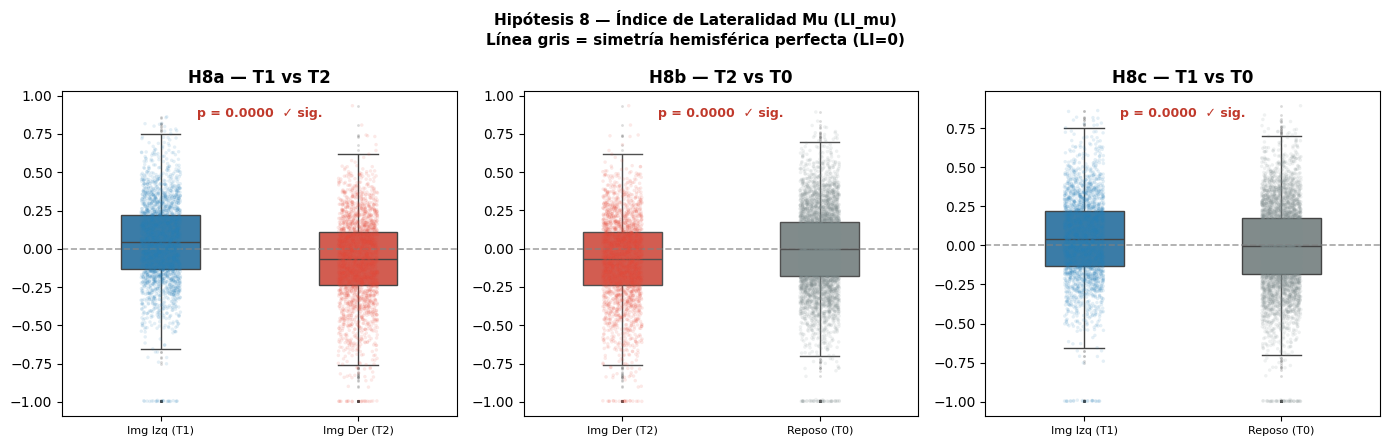

→ Figura guardada: figuras_P2/hipotesis_8_LI_mu.png


In [54]:
# -- Extraer grupos: LI_mu ----------------------------------------
li_mu_T0 = df_features.loc[df_features['tarea'] == 0, 'LI_mu'].dropna().values
li_mu_T1 = df_features.loc[df_features['tarea'] == 1, 'LI_mu'].dropna().values
li_mu_T2 = df_features.loc[df_features['tarea'] == 2, 'LI_mu'].dropna().values

# -- H8: tres sub-hipótesis ----------------------------------------
res_8a = prueba_dos_grupos(li_mu_T1, li_mu_T2, 'T1', 'T2', 'LI_mu', '8a')
res_8b = prueba_dos_grupos(li_mu_T2, li_mu_T0, 'T2', 'T0', 'LI_mu', '8b')
res_8c = prueba_dos_grupos(li_mu_T1, li_mu_T0, 'T1', 'T0', 'LI_mu', '8c')

print('HIPÓTESIS 8 — Índice de Lateralidad Mu (LI_mu)')
print('─' * 65)
for r in [res_8a, res_8b, res_8c]:
    print(f"  H{r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# -- Gráfico H8: boxplot + línea de simetría -----------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares8 = [
    (li_mu_T1, li_mu_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_8a, '7a'),
    (li_mu_T2, li_mu_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_8b, '7b'),
    (li_mu_T1, li_mu_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_8c, '7c'),
]
label_map = {'T0': NOMBRES_CLASE[0], 'T1': NOMBRES_CLASE[1], 'T2': NOMBRES_CLASE[2]}

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares8):
    df_bp = pd.DataFrame({
        'LI_mu': np.concatenate([ga, gb]),
        'Condición': [label_map[la]]*len(ga) + [label_map[lb]]*len(gb)
    })
    sns.boxplot(data=df_bp, x='Condición', y='LI_mu',
                palette=[ca, cb], ax=ax, width=0.4,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    sns.stripplot(data=df_bp, x='Condición', y='LI_mu',
                  palette=[ca, cb], ax=ax, alpha=0.12, size=2.5, jitter=True)
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7, label='Simetría (LI=0)')
    pv = res['p_value']
    ax.annotate(f"p = {pv:.4f}  {'✓ sig.' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.92), xycoords='axes fraction', ha='center',
                fontsize=9, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H8{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('LI Mu  (+= dom. C3, -= dom. C4)' if sid == '8a' else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Hipótesis 8 — Índice de Lateralidad Mu (LI_mu)\n'
             'Línea gris = simetría hemisférica perfecta (LI=0)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_8_LI_mu.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura guardada: figuras_P2/hipotesis_8_LI_mu.png')

---
### **Hipótesis 8. Índice de Lateralidad en banda Beta (LI_beta)**

Mismo índice que LI_mu pero calculado en la banda Beta (13–30 Hz).
La ERD en Beta también tiene componente contralateral durante imaginación motora,
complementando la información de LI_mu.

| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **8a** | T1 vs T2 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **8b** | T2 vs T0 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **8c** | T1 vs T0 | **H₀:** No existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Índice de Lateralidad de la banda Beta (LI_beta) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

HIPÓTESIS 9 — Índice de Lateralidad Beta (LI_beta)
─────────────────────────────────────────────────────────────────
  H8a | T1 vs T2     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
  H8b | T2 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
  H8c | T1 vs T0     | Mann-Whitney U  | p=0.000022 | Rechaza H₀


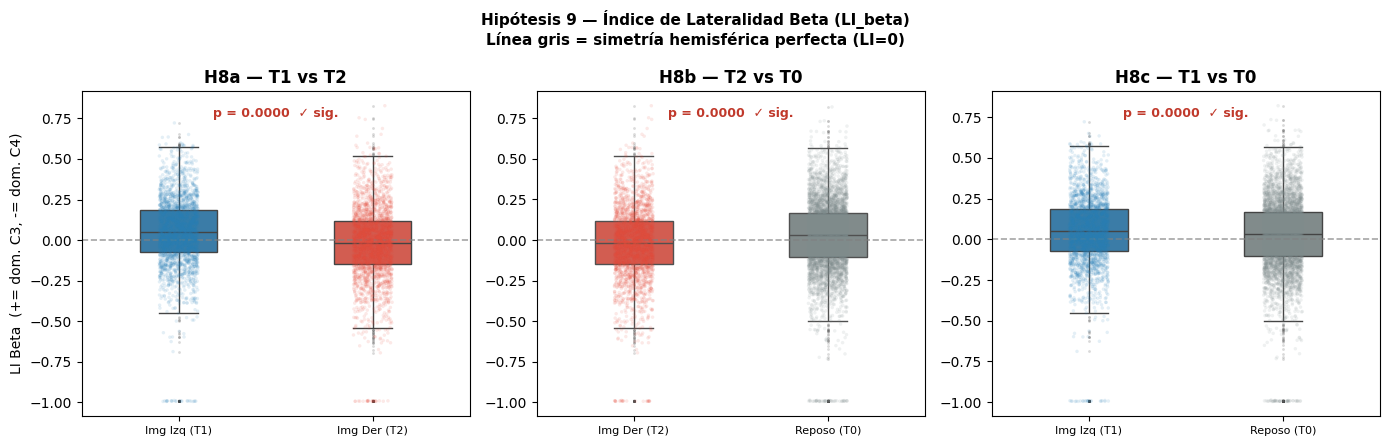

→ Figura guardada: figuras_P2/hipotesis_8_LI_beta.png


In [55]:
# -- Extraer grupos: LI_beta --------------------------------------
li_beta_T0 = df_features.loc[df_features['tarea'] == 0, 'LI_beta'].dropna().values
li_beta_T1 = df_features.loc[df_features['tarea'] == 1, 'LI_beta'].dropna().values
li_beta_T2 = df_features.loc[df_features['tarea'] == 2, 'LI_beta'].dropna().values

# -- H9: tres sub-hipótesis ----------------------------------------
res_9a = prueba_dos_grupos(li_beta_T1, li_beta_T2, 'T1', 'T2', 'LI_beta', '8a')
res_9b = prueba_dos_grupos(li_beta_T2, li_beta_T0, 'T2', 'T0', 'LI_beta', '8b')
res_9c = prueba_dos_grupos(li_beta_T1, li_beta_T0, 'T1', 'T0', 'LI_beta', '8c')

print('HIPÓTESIS 9 — Índice de Lateralidad Beta (LI_beta)')
print('─' * 65)
for r in [res_9a, res_9b, res_9c]:
    print(f"  H{r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# -- Gráfico H9 ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares9 = [
    (li_beta_T1, li_beta_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_9a, '8a'),
    (li_beta_T2, li_beta_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_9b, '8b'),
    (li_beta_T1, li_beta_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_9c, '8c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares9):
    df_bp = pd.DataFrame({
        'LI_beta': np.concatenate([ga, gb]),
        'Condición': [label_map[la]]*len(ga) + [label_map[lb]]*len(gb)
    })
    sns.boxplot(data=df_bp, x='Condición', y='LI_beta',
                palette=[ca, cb], ax=ax, width=0.4,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    sns.stripplot(data=df_bp, x='Condición', y='LI_beta',
                  palette=[ca, cb], ax=ax, alpha=0.12, size=2.5, jitter=True)
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7)
    pv = res['p_value']
    ax.annotate(f"p = {pv:.4f}  {'✓ sig.' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.92), xycoords='axes fraction', ha='center',
                fontsize=9, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H8{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('LI Beta  (+= dom. C3, -= dom. C4)' if sid == '8a' else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Hipótesis 9 — Índice de Lateralidad Beta (LI_beta)\n'
             'Línea gris = simetría hemisférica perfecta (LI=0)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_9_LI_beta.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura guardada: figuras_P2/hipotesis_8_LI_beta.png')

---
### **Hipótesis 9 — Diferencia de entropía muestral interhemisférica (sampen_diff)**

`sampen_diff = SampEn(C3) - SampEn(C4)` captura la **asimetría de complejidad**
entre hemisferios. Un solo canal (SampEn_C3) no distinguía T1 de T2 (p=0.69)
porque ambos hemisferios se desconsincronizan por igual.
La **diferencia** entre ellos sí debería variar con la lateralidad:
- T2 (Img Der): C3 más irregular que C4 → diff > 0
- T1 (Img Izq): C4 más irregular que C3 → diff < 0

| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **9a** | T1 vs T2 | **H₀:** No existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **9b** | T2 vs T0 | **H₀:** No existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **9c** | T1 vs T0 | **H₀:** No existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la diferencia de entropía muestral interhemisférica (sampen_diff) entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

HIPÓTESIS 10 — SampEn Diff interhemisférico (sampen_diff)
─────────────────────────────────────────────────────────────────
  H10a | T1 vs T2     | Mann-Whitney U  | p=0.001553 | Rechaza H₀
  H10b | T2 vs T0     | Mann-Whitney U  | p=0.000958 | Rechaza H₀
  H10c | T1 vs T0     | Mann-Whitney U  | p=0.745447 | No rechaza H₀


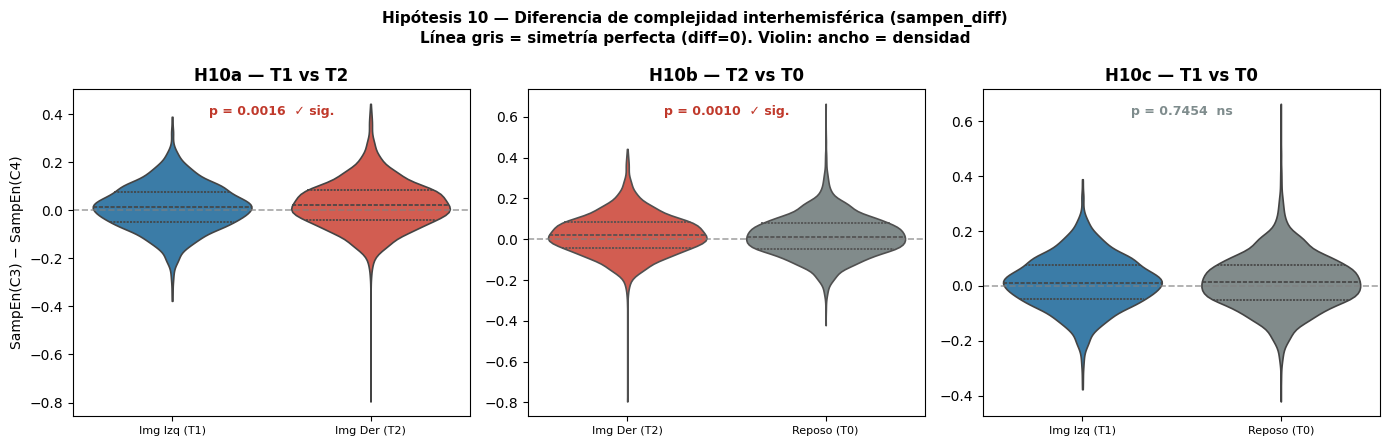

→ Figura guardada: figuras_P2/hipotesis_10_sampen_diff.png


In [56]:
# -- Extraer grupos: sampen_diff ----------------------------------
sd_T0 = df_features.loc[df_features['tarea'] == 0, 'sampen_diff'].dropna().values
sd_T1 = df_features.loc[df_features['tarea'] == 1, 'sampen_diff'].dropna().values
sd_T2 = df_features.loc[df_features['tarea'] == 2, 'sampen_diff'].dropna().values

# -- H10: tres sub-hipótesis ---------------------------------------
res_10a = prueba_dos_grupos(sd_T1, sd_T2, 'T1', 'T2', 'SampEn_diff', '10a')
res_10b = prueba_dos_grupos(sd_T2, sd_T0, 'T2', 'T0', 'SampEn_diff', '10b')
res_10c = prueba_dos_grupos(sd_T1, sd_T0, 'T1', 'T0', 'SampEn_diff', '10c')

print('HIPÓTESIS 10 — SampEn Diff interhemisférico (sampen_diff)')
print('─' * 65)
for r in [res_10a, res_10b, res_10c]:
    print(f"  H{r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# -- Gráfico H10: violin (distribución asimétrica esperada) --------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares10 = [
    (sd_T1, sd_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_10a, '10a'),
    (sd_T2, sd_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_10b, '10b'),
    (sd_T1, sd_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_10c, '10c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares10):
    df_vp = pd.DataFrame({
        'SampEn_diff': np.concatenate([ga, gb]),
        'Condición': [label_map[la]]*len(ga) + [label_map[lb]]*len(gb)
    })
    sns.violinplot(data=df_vp, x='Condición', y='SampEn_diff',
                   palette=[ca, cb], ax=ax, inner='quartile',
                   cut=0, linewidth=1.2)
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7,
               label='Sin asimetría (diff=0)')
    pv = res['p_value']
    ax.annotate(f"p = {pv:.4f}  {'✓ sig.' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.92), xycoords='axes fraction', ha='center',
                fontsize=9, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H10{sid[2:]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('SampEn(C3) − SampEn(C4)' if sid == '10a' else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Hipótesis 10 — Diferencia de complejidad interhemisférica (sampen_diff)\n'
             'Línea gris = simetría perfecta (diff=0). Violin: ancho = densidad',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_10_sampen_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura guardada: figuras_P2/hipotesis_10_sampen_diff.png')

### **Resumen global. 25 hipótesis del proyecto**

Juntamos los resultados de todas las hipótesis en una sola tabla
y un gráfico de -log₁₀(p) para verlas comparadas.
Las barras que superan la línea roja son estadísticamente significativas.

Bloques:
- **H1–3b** (4): PSD — retomado del Proyecto 1
- **H5** (6): Hjorth Actividad y Complejidad en C3 (Movilidad eliminada)
- **H6** (3): Sample Entropy C3
- **H7** (3): PLV Mu C3–C4
- **H8** (3): Índice de Lateralidad Mu (LI_mu) ← nuevo
- **H9** (3): Índice de Lateralidad Beta (LI_beta) ← nuevo
- **H10** (3): SampEn diferencial interhemisférico (sampen_diff) ← nuevo


RESUMEN COMPLETO — 22 HIPÓTESIS
 id       variable   grupos         prueba      p_value      decision
  1      PSD Mu C3 T1 vs T2 Mann-Whitney U 3.128291e-02    Rechaza H₀
  2    PSD Beta C4 T1 vs T2 Mann-Whitney U 7.042284e-03    Rechaza H₀
 3a      PSD Mu C3 T2 vs T0 Mann-Whitney U 7.417997e-16    Rechaza H₀
 3b      PSD Mu C3 T1 vs T0 Mann-Whitney U 2.197663e-08    Rechaza H₀
 5a  Hjorth Act C3 T1 vs T2 Mann-Whitney U 9.435000e-02 No rechaza H₀
 5b  Hjorth Act C3 T2 vs T0 Mann-Whitney U 0.000000e+00    Rechaza H₀
 5c  Hjorth Act C3 T1 vs T0 Mann-Whitney U 1.000000e-06    Rechaza H₀
 5a Hjorth Comp C3 T1 vs T2 Mann-Whitney U 7.609380e-01 No rechaza H₀
 5b Hjorth Comp C3 T2 vs T0 Mann-Whitney U 4.328700e-02    Rechaza H₀
 5c Hjorth Comp C3 T1 vs T0 Mann-Whitney U 2.079100e-02    Rechaza H₀
 6a      SampEn C3 T1 vs T2 Mann-Whitney U 6.655820e-01 No rechaza H₀
 6b      SampEn C3 T2 vs T0 Mann-Whitney U 0.000000e+00    Rechaza H₀
 6c      SampEn C3 T1 vs T0 Mann-Whitney U 0.000000e+00   

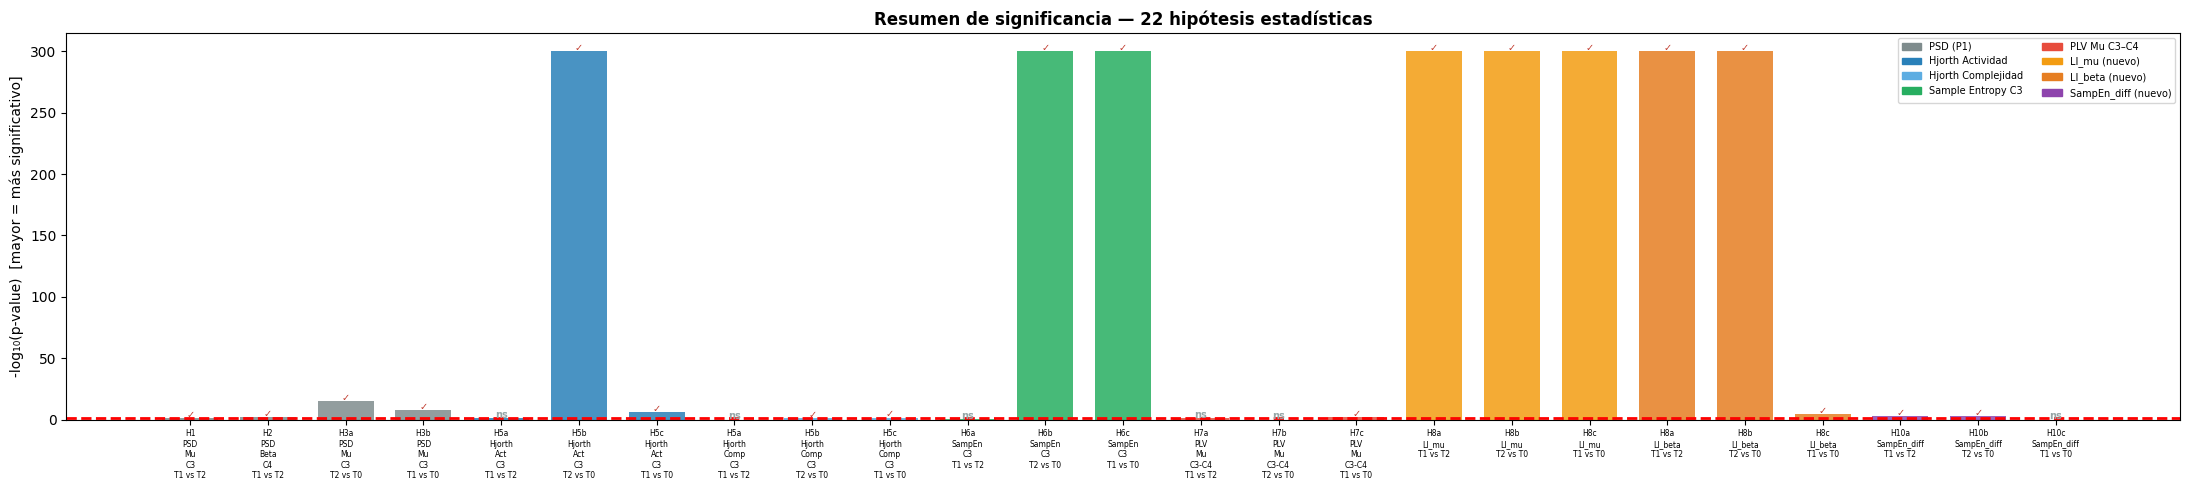

→ Figura guardada: figuras_P2/hipotesis_resumen_22.png

SIGNIFICATIVAS POR BLOQUE:
  PSD (H1-3b)                        : 4/4 significativas
  Hjorth Actividad (H5)              : 2/3 significativas
  Hjorth Complejidad (H5)            : 2/3 significativas
  SampEn C3 (H6)                     : 2/3 significativas
  PLV Mu C3-C4 (H7)                  : 1/3 significativas
  LI_mu (H8)                         : 3/3 significativas
  LI_beta (H9)                       : 3/3 significativas
  SampEn_diff (H10)                  : 2/3 significativas


In [57]:
# -- Tabla con todas las hipótesis -------------------------------
todos_res = [
    # Bloque 1: PSD (retomado del Proyecto 1)
    {'id':'1',   'variable':'PSD Mu C3',    'grupos':'T1 vs T2',
     'prueba':prueba_nombre, 'p_value':p_val,   'decision':'Rechaza H₀' if p_val<0.05   else 'No rechaza H₀'},
    {'id':'2',   'variable':'PSD Beta C4',  'grupos':'T1 vs T2',
     'prueba':prueba2,       'p_value':p_val2,  'decision':'Rechaza H₀' if p_val2<0.05  else 'No rechaza H₀'},
    {'id':'3a',  'variable':'PSD Mu C3',    'grupos':'T2 vs T0',
     'prueba':prueba3a,      'p_value':p_val3a, 'decision':'Rechaza H₀' if p_val3a<0.05 else 'No rechaza H₀'},
    {'id':'3b',  'variable':'PSD Mu C3',    'grupos':'T1 vs T0',
     'prueba':prueba3b,      'p_value':p_val3b, 'decision':'Rechaza H₀' if p_val3b<0.05 else 'No rechaza H₀'},
    # Bloque 2: Hjorth Actividad C3
    res_5a_act, res_5b_act, res_5c_act,
    # Bloque 3: Hjorth Complejidad C3
    res_5a_comp, res_5b_comp, res_5c_comp,
    # Bloque 4: Sample Entropy C3
    res_6a, res_6b, res_6c,
    # Bloque 5: PLV Mu C3-C4
    res_7a, res_7b, res_7c,
    # Bloque 6: LI_mu
    res_8a, res_8b, res_8c,
    # Bloque 7: LI_beta
    res_9a, res_9b, res_9c,
    # Bloque 8: sampen_diff
    res_10a, res_10b, res_10c,
]

df_resumen = pd.DataFrame(todos_res)[['id','variable','grupos','prueba','p_value','decision']]
print('RESUMEN COMPLETO — 22 HIPÓTESIS')
print('='*90)
print(df_resumen.to_string(index=False))

# -- Gráfico: -log10(p) de las 22 hipótesis ----------------------
etiq = [f"H{r['id']}\n{r['variable'].replace(' ','\n')}\n{r['grupos']}"
        for r in todos_res]
pvals_all = [r['p_value'] for r in todos_res]
log_p_all = [-np.log10(p + 1e-300) for p in pvals_all]

colores_bloques = (
    ['#7F8C8D'] * 4 +   # PSD
    ['#2980B9'] * 3 +   # Hjorth Act
    ['#5DADE2'] * 3 +   # Hjorth Comp
    ['#27AE60'] * 3 +   # SampEn
    ['#E74C3C'] * 3 +   # PLV
    ['#F39C12'] * 3 +   # LI_mu
    ['#E67E22'] * 3 +   # LI_beta
    ['#8E44AD'] * 3     # sampen_diff
)

fig, ax = plt.subplots(figsize=(22, 5))
bars = ax.bar(range(len(pvals_all)), log_p_all,
              color=colores_bloques, alpha=0.85, width=0.72)
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=2, label='Umbral p=0.05')

for bar, pv in zip(bars, pvals_all):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.15,
            '✓' if pv < 0.05 else 'ns',
            ha='center', fontsize=7, fontweight='bold',
            color='#c0392b' if pv < 0.05 else '#95a5a6')

ax.set_xticks(range(len(pvals_all)))
ax.set_xticklabels(etiq, fontsize=5.5)
ax.set_ylabel('-log₁₀(p-value)  [mayor = más significativo]')
ax.set_title('Resumen de significancia — 22 hipótesis estadísticas', fontweight='bold')

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#7F8C8D', label='PSD (P1)'),
    Patch(color='#2980B9', label='Hjorth Actividad'),
    Patch(color='#5DADE2', label='Hjorth Complejidad'),
    Patch(color='#27AE60', label='Sample Entropy C3'),
    Patch(color='#E74C3C', label='PLV Mu C3–C4'),
    Patch(color='#F39C12', label='LI_mu (nuevo)'),
    Patch(color='#E67E22', label='LI_beta (nuevo)'),
    Patch(color='#8E44AD', label='SampEn_diff (nuevo)'),
]
ax.legend(handles=leyenda, loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_resumen_22.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura guardada: figuras_P2/hipotesis_resumen_22.png')

print()
print('SIGNIFICATIVAS POR BLOQUE:')
bloques = {
    'PSD (H1-3b)'              : todos_res[:4],
    'Hjorth Actividad (H5)'    : todos_res[4:7],
    'Hjorth Complejidad (H5)'  : todos_res[7:10],
    'SampEn C3 (H6)'           : todos_res[10:13],
    'PLV Mu C3-C4 (H7)'        : todos_res[13:16],
    'LI_mu (H8)'               : todos_res[16:19],
    'LI_beta (H9)'             : todos_res[19:22],
    'SampEn_diff (H10)'        : todos_res[22:25] if len(todos_res)>22 else [],
}
for bloque, rlist in bloques.items():
    if rlist:
        sig = sum(1 for r in rlist if r['p_value'] < 0.05)
        print(f'  {bloque:35s}: {sig}/{len(rlist)} significativas')


#### **9.B. Kruskal-Wallis: selección de características significativas**

Aplicamos el test a cada una de las 19 características para los 3 grupos simultáneos.
Guardamos en `feats_significativas` solo las que tengan p < 0.05.
Estas son las únicas que usaremos en los modelos de clasificación.

Paso previo: Normalización por sujeto (z-score intrasujeto)

Antes de aplicar el Kruskal-Wallis y de entrenar los modelos, normalizamos
las características **dentro de cada sujeto**.

**¿Por qué?** Cada persona tiene una amplitud basal de EEG diferente.
Sin normalizar, el clasificador aprende *quién es el sujeto* en lugar de
*qué condición está haciendo*. Con z-score intrasujeto eliminamos ese
efecto antes de cualquier análisis estadístico o clasificación.

> Importante: aplicamos esto **antes** del Kruskal-Wallis para que
> la selección de features y el entrenamiento del modelo sean consistentes
> (ambos ven los mismos datos normalizados).


In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ── Normalización z-score por sujeto ─────────────────────────────
cols_meta = ['sujeto', 'run', 'tarea']
cols_feat = [c for c in df_features.columns if c not in cols_meta]

df_norm = df_features.copy()

for suj in df_norm['sujeto'].unique():
    mask = df_norm['sujeto'] == suj
    if mask.sum() > 1:   # necesitamos al menos 2 épocas para calcular std
        df_norm.loc[mask, cols_feat] = (
            StandardScaler().fit_transform(df_norm.loc[mask, cols_feat])
        )

# Verificar que funcionó
media_post = df_norm.groupby('sujeto')[cols_feat].mean().values.mean()
std_post   = df_norm.groupby('sujeto')[cols_feat].std().values.mean()
print('Normalización por sujeto aplicada:')
print(f'  Media intrasujeto promedio : {media_post:.4f}  (esperado ≈ 0)')
print(f'  Std  intrasujeto promedio  : {std_post:.4f}  (esperado ≈ 1)')
print(f'  Características normalizadas: {len(cols_feat)}')
print(f'  Sujetos procesados          : {df_norm["sujeto"].nunique()}')

# df_norm es el que usaremos a partir de aquí
# (tanto para Kruskal como para los modelos)
print('\n→ df_norm listo. El Kruskal-Wallis y los modelos usarán estos datos.')


Normalización por sujeto aplicada:
  Media intrasujeto promedio : 0.0000  (esperado ≈ 0)
  Std  intrasujeto promedio  : 1.0056  (esperado ≈ 1)
  Características normalizadas: 19
  Sujetos procesados          : 109

→ df_norm listo. El Kruskal-Wallis y los modelos usarán estos datos.


In [59]:
from scipy.stats import kruskal

# -- Kruskal-Wallis sobre todas las características (datos normalizados) --
# Usamos df_norm (ya normalizado por sujeto) para que la selección de
# features sea consistente con los datos que verá el clasificador.
# H0: las medianas de los 3 grupos son iguales
# H1: al menos un grupo tiene mediana diferente

resultados_kw = {}

for col in cols_feat:
    g0 = df_norm.loc[df_norm['tarea'] == 0, col].dropna().values
    g1 = df_norm.loc[df_norm['tarea'] == 1, col].dropna().values
    g2 = df_norm.loc[df_norm['tarea'] == 2, col].dropna().values

    if len(g0) < 2 or len(g1) < 2 or len(g2) < 2:
        continue

    stat_kw, p_kw = kruskal(g0, g1, g2)

    # Tamaño del efecto: eta cuadrado (η²)
    N_total = len(g0) + len(g1) + len(g2)
    k = 3
    eta2 = max(0, (stat_kw - k + 1) / (N_total - k))

    resultados_kw[col] = {
        'H_statistic' : round(stat_kw, 4),
        'p_value'     : round(p_kw, 6),
        'eta2'        : round(eta2, 4),
        'significativa': p_kw < 0.05
    }

df_kruskal = pd.DataFrame(resultados_kw).T.sort_values('p_value')

print('RESULTADOS KRUSKAL-WALLIS — datos normalizados por sujeto')
print('='*65)
print(df_kruskal.to_string())

feats_significativas = df_kruskal[df_kruskal['significativa'] == True].index.tolist()

print(f'\n→ Total características : {len(cols_feat)}')
print(f'→ Significativas (p<0.05): {len(feats_significativas)}')
print(f'→ Se usarán en los modelos: {feats_significativas}')


# -- Fallback: si no hay ninguna significativa usar todas ----------
# (no debería pasar con datos reales, pero evita NameError en celdas siguientes)
if not feats_significativas:
    print('AVISO: ninguna feature significativa — usando todas como fallback')
    feats_significativas = cols_feat.copy()


RESULTADOS KRUSKAL-WALLIS — datos normalizados por sujeto
               H_statistic   p_value    eta2 significativa
psd_mu_C3         477.5302       0.0  0.0485          True
psd_beta_C3          826.7       0.0   0.084          True
hjorth_act_C3     745.4396       0.0  0.0758          True
sampen_C3         115.8864       0.0  0.0116          True
psd_mu_Cz         204.3018       0.0  0.0206          True
psd_beta_Cz       405.0935       0.0  0.0411          True
hjorth_act_Cz     322.6873       0.0  0.0327          True
LI_beta            262.953       0.0  0.0266          True
psd_mu_C4         501.3285       0.0  0.0509          True
psd_beta_C4       623.6285       0.0  0.0633          True
hjorth_act_C4     616.1085       0.0  0.0626          True
LI_mu             273.1108       0.0  0.0276          True
sampen_C4          99.9369       0.0    0.01          True
hjorth_comp_Cz     28.4647  0.000001  0.0027          True
hjorth_comp_C3     23.3617  0.000008  0.0022          Tru

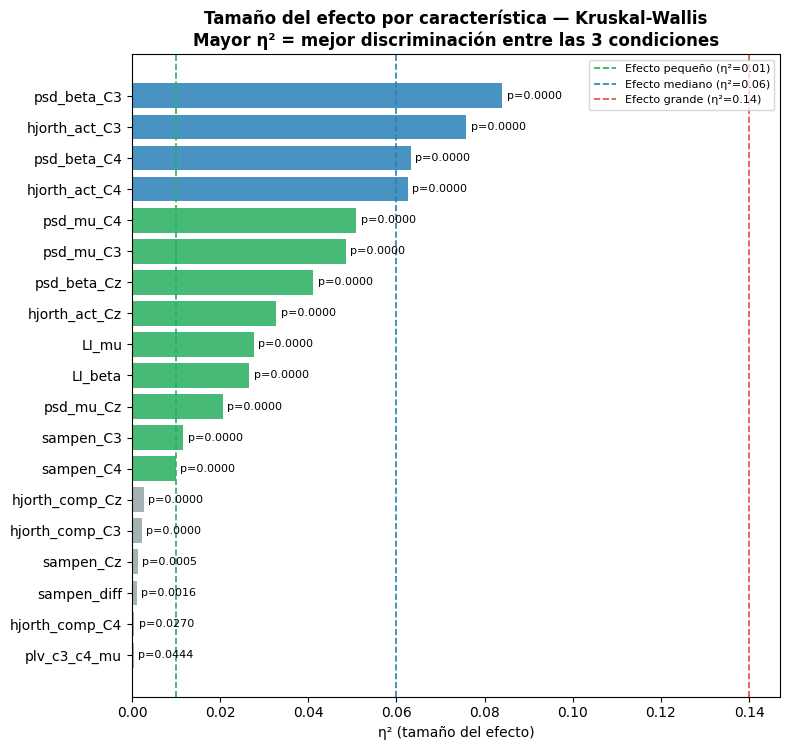

Figura guardada: figuras_P2/hipotesis_00_kruskal_wallis.png


In [60]:
# ── Gráfico: η² de las características significativas ────────────
# El tamaño del efecto nos dice cuánto discrimina cada feature,
# independientemente del p-value (que con N grande casi siempre es < 0.05)

df_sig = df_kruskal[df_kruskal['significativa'] == True].sort_values('eta2', ascending=True)

if len(df_sig) == 0:
    print('Ninguna característica resultó significativa. Revisar los datos.')
else:
    fig, ax = plt.subplots(figsize=(8, max(4, len(df_sig) * 0.4)))

    colores_bar_kw = ['#2980B9' if e >= 0.06 else
                      '#27AE60' if e >= 0.01 else
                      '#95A5A6'
                      for e in df_sig['eta2']]

    barras = ax.barh(df_sig.index, df_sig['eta2'],
                     color=colores_bar_kw, alpha=0.85)

    # Líneas de referencia del tamaño del efecto
    ax.axvline(0.01, ls='--', color='#27AE60', lw=1.2, label='Efecto pequeño (η²=0.01)')
    ax.axvline(0.06, ls='--', color='#2980B9', lw=1.2, label='Efecto mediano (η²=0.06)')
    ax.axvline(0.14, ls='--', color='#E74C3C', lw=1.2, label='Efecto grande (η²=0.14)')

    for bar, (_, row) in zip(barras, df_sig.iterrows()):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'p={row["p_value"]:.4f}',
                va='center', fontsize=8)

    ax.set_xlabel('η² (tamaño del efecto)')
    ax.set_title('Tamaño del efecto por característica — Kruskal-Wallis\n'
                 'Mayor η² = mejor discriminación entre las 3 condiciones',
                 fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('figuras_P2/hipotesis_00_kruskal_wallis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: figuras_P2/hipotesis_00_kruskal_wallis.png')


In [61]:
# -- Verificación de dependencias antes de clasificar ---------------
# Esta celda comprueba que todas las variables necesarias existen.
# Si alguna falta, indica qué celda ejecutar primero.

dependencias = {
    'df_features'         : 'Celda 27 — Pipeline poblacional (cargar CSV)',
    'df_norm'             : 'Celda 71 — Normalización por sujeto',
    'feats_significativas': 'Celda 72 — Kruskal-Wallis',
    'resultados_kw'       : 'Celda 72 — Kruskal-Wallis',
    'cols_feat'           : 'Celda 29 — Definición de columnas',
}

todas_ok = True
for var, instruccion in dependencias.items():
    existe = var in dir()
    estado = '✔' if existe else '✗ FALTA'
    if not existe:
        todas_ok = False
    print(f'  {estado}  {var:30s}  → {instruccion}')

print()
if todas_ok:
    print('✔ Todas las dependencias OK — puedes ejecutar la clasificación')
else:
    print('✗ Ejecuta las celdas marcadas con ✗ antes de continuar')

  ✔  df_features                     → Celda 27 — Pipeline poblacional (cargar CSV)
  ✔  df_norm                         → Celda 71 — Normalización por sujeto
  ✔  feats_significativas            → Celda 72 — Kruskal-Wallis
  ✔  resultados_kw                   → Celda 72 — Kruskal-Wallis
  ✔  cols_feat                       → Celda 29 — Definición de columnas

✔ Todas las dependencias OK — puedes ejecutar la clasificación



## **10. Clasificación con K-Fold Estratificado**

### ¿Qué es el K-Fold Estratificado?
En lugar de dividir los datos una sola vez en train/test,
dividimos **5 veces** asegurándonos de que en cada fold
las 3 clases estén proporcionalmente representadas.
Esto da una estimación más robusta del desempeño real del modelo.

### Reglas heurísticas para diseño de arquitecturas MLP

El número de features de entrada (`N_IN`) se calcula dinámicamente
a partir del Kruskal-Wallis — es `len(feats_significativas)`.
La siguiente celda calcula las arquitecturas con ese valor real.

Las 3 reglas heurísticas son:

| Regla | Fórmula | Qué controla |
|---|---|---|
| **Regla 1** — Entre entrada y salida | `salidas ≤ n_ocultas ≤ entradas` | Rango válido de neuronas |
| **Regla 2** — 2/3 de entrada + salida | `≈ 2/3 × N_IN + N_OUT` | Tamaño sugerido (arquitectura base) |
| **Regla 3** — Menos del doble de entrada | `< 2 × N_IN` | Límite superior para no sobredimensionar |

Estas reglas son un punto de partida, no son absolutas.
Una red con demasiadas neuronas para pocas features tiende al
**overfitting** — memoriza el training pero no generaliza.

### Corrección al pipeline

**Balanceo de clases** (modelos y loop K-Fold)

Si T0 tiene más épocas que T1 y T2, el clasificador aprende que predecir
siempre T0 da buen accuracy pero pésimo F1-macro.
Solución: `class_weight='balanced'` en SVM
y `sample_weight` en el `fit()` de MLP y XGBoost.


In [62]:
# -- Guard: verificar que Kruskal-Wallis se ejecutó antes -----------
if 'feats_significativas' not in dir() or not feats_significativas:
    raise RuntimeError(
        "Ejecuta primero la celda del Kruskal-Wallis (sección 9B) "
        "para definir feats_significativas antes de entrenar los modelos."
    )

# -- Definir los modelos a comparar -------------------------------
#
# N_IN se toma de feats_significativas (resultado del Kruskal-Wallis)
# para que las arquitecturas siempre reflejen el problema real.

N_IN  = len(feats_significativas)   # dinámico: depende del Kruskal
N_OUT = 3                           # siempre 3 clases: T0, T1, T2

r1_max = N_IN                           # Regla 1 máximo
r2     = round((2/3) * N_IN + N_OUT)   # Regla 2 sugerido
r3_max = 2 * N_IN - 1                  # Regla 3 máximo

print(f'Features significativas (N_IN) : {N_IN}')
print(f'Clases (N_OUT)                 : {N_OUT}')
print(f'  Regla 1 → rango neuronas ocultas : [{N_OUT}, {r1_max}]')
print(f'  Regla 2 → neuronas sugeridas     : {r2}')
print(f'  Regla 3 → máximo neuronas        : < {r3_max + 1}')
print()

def get_modelos():
    modelos = {

        # -- MLP_R2: Regla 2 — 1 capa oculta, tamaño ≈ 2/3·N_IN + N_OUT --
        # La más minimalista. Una sola capa con el tamaño sugerido por la
        # Regla 2. Sirve de referencia base (arquitectura más sencilla).
        'MLP_R2': MLPClassifier(
            hidden_layer_sizes=(r2,),
            activation='relu',
            solver='adam',
            max_iter=1000,
            random_state=42
        ),

        # -- MLP_R1: Regla 1 — 2 capas decrecientes dentro de [N_OUT, N_IN] --
        # Estructura "embudo": la primera capa toma el máximo de Regla 1
        # y la segunda el punto medio entre entrada y salida.
        # Es la arquitectura más usada en la práctica para este tipo de problema.
        'MLP_R1': MLPClassifier(
            hidden_layer_sizes=(r1_max, (N_IN + N_OUT) // 2),
            activation='relu',
            solver='adam',
            alpha=0.001,
            max_iter=1000,
            random_state=42
        ),

        # -- MLP_R3: Regla 3 — 2 capas, dentro del límite < 2·N_IN ----------
        # La más grande de las tres, pero aún dentro del límite de la Regla 3.
        # Usa tanh en lugar de relu para comparar funciones de activación y
        # tiene más capacidad para capturar no-linealidades.
        'MLP_R3': MLPClassifier(
            hidden_layer_sizes=(r3_max, round(r3_max * 2/3)),
            activation='tanh',
            solver='adam',
            learning_rate='adaptive',
            alpha=0.0001,
            max_iter=1000,
            random_state=42
        ),

        # -- SVM con kernel RBF --------------------------------------------
        'SVM_RBF': SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            class_weight='balanced',
            random_state=42
        ),
    }

    if XGB_OK:
        modelos['XGBoost'] = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        )
    return modelos

print('Modelos configurados (arquitecturas calculadas con N_IN real):')
for nombre, clf in get_modelos().items():
    if 'MLP' in nombre:
        capas = clf.hidden_layer_sizes
        if isinstance(capas, int):
            capas = (capas,)
        ok = all(N_OUT <= c <= r3_max + 1 for c in capas)
        estado = '✔ cumple heurísticas' if ok else '✗ fuera de rango'
        print(f'  {nombre:12s} capas={capas}  {estado}')
    else:
        print(f'  {nombre}')


Features significativas (N_IN) : 19
Clases (N_OUT)                 : 3
  Regla 1 → rango neuronas ocultas : [3, 19]
  Regla 2 → neuronas sugeridas     : 16
  Regla 3 → máximo neuronas        : < 38

Modelos configurados (arquitecturas calculadas con N_IN real):
  MLP_R2       capas=(16,)  ✔ cumple heurísticas
  MLP_R1       capas=(19, 11)  ✔ cumple heurísticas
  MLP_R3       capas=(37, 25)  ✔ cumple heurísticas
  SVM_RBF
  XGBoost


In [63]:
# -- Guard: verificar que Kruskal-Wallis se ejecutó antes -----------
if 'feats_significativas' not in dir() or not feats_significativas:
    raise RuntimeError(
        "Ejecuta primero la celda del Kruskal-Wallis (sección 9B) "
        "para definir feats_significativas antes de entrenar los modelos."
    )

# -- Preparar X e y para los modelos ------------------------------
# Usamos df_norm (ya normalizado por sujeto, antes del Kruskal)
# y solo las features significativas identificadas por Kruskal-Wallis.
# No repetimos la normalización aquí para evitar inconsistencia.

X = df_norm[feats_significativas].values
y = df_norm['tarea'].values

print('Features que entran a los modelos:')
print(f'  Total disponibles       : {len(cols_feat)}')
print(f'  Significativas (p<0.05) : {len(feats_significativas)}')
for f in feats_significativas:
    eta = resultados_kw[f]['eta2']
    print(f'  {f:<30} eta²={eta:.4f}')

print(f'\nShape de X : {X.shape}   (épocas × características)')
print(f'Shape de y : {y.shape}')

print('\nDistribución de clases:')
for t, nombre in NOMBRES_CLASE.items():
    n = np.sum(y == t)
    print(f'  {nombre}: {n} épocas ({n/len(y)*100:.1f}%)')

# -- Pesos por clase para balanceo --------------------------------
pesos_array = compute_class_weight('balanced', classes=np.unique(y), y=y)
pesos_dict  = dict(enumerate(pesos_array))

print('\nPesos por clase (class_weight balanced):')
for clase, peso in pesos_dict.items():
    print(f'  {NOMBRES_CLASE[clase]}: {peso:.3f}')
print('  (peso > 1 = clase subrepresentada, se penaliza más si se falla)')


Features que entran a los modelos:
  Total disponibles       : 19
  Significativas (p<0.05) : 19
  psd_mu_C3                      eta²=0.0485
  psd_beta_C3                    eta²=0.0840
  hjorth_act_C3                  eta²=0.0758
  sampen_C3                      eta²=0.0116
  psd_mu_Cz                      eta²=0.0206
  psd_beta_Cz                    eta²=0.0411
  hjorth_act_Cz                  eta²=0.0327
  LI_beta                        eta²=0.0266
  psd_mu_C4                      eta²=0.0509
  psd_beta_C4                    eta²=0.0633
  hjorth_act_C4                  eta²=0.0626
  LI_mu                          eta²=0.0276
  sampen_C4                      eta²=0.0100
  hjorth_comp_Cz                 eta²=0.0027
  hjorth_comp_C3                 eta²=0.0022
  sampen_Cz                      eta²=0.0013
  sampen_diff                    eta²=0.0011
  hjorth_comp_C4                 eta²=0.0005
  plv_c3_c4_mu                   eta²=0.0004

Shape de X : (9816, 19)   (épocas × característ

In [64]:
# -- Loop principal K-Fold -----------------------------------------
from sklearn.utils.class_weight import compute_sample_weight

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelos = get_modelos()

resultados = {nombre: {'acc': [], 'f1': [], 'prec': [], 'rec': []}
              for nombre in modelos}

# Modelos que aceptan sample_weight en fit()
# (MLP de sklearn y XGBoost sí lo aceptan; SVM ya tiene class_weight)
MODELOS_CON_SW = {'MLP_Simple', 'MLP_Profunda', 'MLP_Ancha', 'XGBoost'}

print('Entrenando con K-Fold estratificado (5 folds)...')
print('Correcciones activas:')
print('  ✔ X normalizado por sujeto (z-score intrasujeto)')
print('  ✔ SVM: class_weight=balanced')
print('  ✔ MLP/XGBoost: sample_weight proporcional a clase')
print('='*55)

for fold, (idx_train, idx_test) in enumerate(skf.split(X, y)):
    print(f'Fold {fold+1}/5 ', end='')

    X_tr, X_te = X[idx_train], X[idx_test]
    y_tr, y_te = y[idx_train], y[idx_test]

    # Escalar DENTRO del fold (evitar data leakage)
    # Nota: X ya viene normalizado por sujeto, pero escalamos también
    # dentro del fold para eliminar cualquier diferencia de escala
    # residual entre los folds de train y test.
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # sample_weight para este fold de entrenamiento
    # compute_sample_weight asigna más peso a clases con menos épocas
    sw_tr = compute_sample_weight('balanced', y_tr)

    for nombre, clf in modelos.items():
        if nombre in MODELOS_CON_SW:
            # MLP y XGBoost: pasar sample_weight al fit()
            clf.fit(X_tr_sc, y_tr, sample_weight=sw_tr)
        else:
            # SVM ya tiene class_weight='balanced' en el constructor
            clf.fit(X_tr_sc, y_tr)

        y_pred = clf.predict(X_te_sc)

        resultados[nombre]['acc'].append(
            accuracy_score(y_te, y_pred))
        resultados[nombre]['f1'].append(
            f1_score(y_te, y_pred, average='macro', zero_division=0))
        resultados[nombre]['prec'].append(
            precision_score(y_te, y_pred, average='macro', zero_division=0))
        resultados[nombre]['rec'].append(
            recall_score(y_te, y_pred, average='macro', zero_division=0))

    print('OK')

print('\nEntrenamiento completado.')


Entrenando con K-Fold estratificado (5 folds)...
Correcciones activas:
  ✔ X normalizado por sujeto (z-score intrasujeto)
  ✔ SVM: class_weight=balanced
  ✔ MLP/XGBoost: sample_weight proporcional a clase
Fold 1/5 OK
Fold 2/5 OK
Fold 3/5 OK
Fold 4/5 OK
Fold 5/5 OK

Entrenamiento completado.



## **11. Resultados: tabla comparativa de métricas**

Mostramos media ± desviación estándar de cada métrica sobre los 5 folds.
La desviación estándar nos dice qué tan estable es el modelo:
un std alto significa que el rendimiento cambia mucho dependiendo de qué
datos le toca en cada fold (poca robustez).


In [65]:
filas_tabla = []
for nombre, res in resultados.items():
    filas_tabla.append({
        'Modelo'    : nombre,
        'Accuracy'  : f"{np.mean(res['acc']):.3f} ± {np.std(res['acc']):.3f}",
        'F1-macro'  : f"{np.mean(res['f1']):.3f}  ± {np.std(res['f1']):.3f}",
        'Precision' : f"{np.mean(res['prec']):.3f} ± {np.std(res['prec']):.3f}",
        'Recall'    : f"{np.mean(res['rec']):.3f}  ± {np.std(res['rec']):.3f}",
    })

df_tabla = pd.DataFrame(filas_tabla)
print(df_tabla.to_string(index=False))


 Modelo      Accuracy       F1-macro     Precision         Recall
 MLP_R2 0.543 ± 0.010 0.452  ± 0.008 0.497 ± 0.014 0.452  ± 0.007
 MLP_R1 0.529 ± 0.009 0.445  ± 0.009 0.474 ± 0.008 0.445  ± 0.009
 MLP_R3 0.470 ± 0.010 0.416  ± 0.011 0.419 ± 0.011 0.415  ± 0.010
SVM_RBF 0.468 ± 0.012 0.447  ± 0.012 0.450 ± 0.011 0.455  ± 0.012
XGBoost 0.488 ± 0.012 0.462  ± 0.013 0.462 ± 0.013 0.467  ± 0.014



## **12. Resultados: tabla comparativa de métricas**

Mostramos media ± desviación estándar de cada métrica sobre los 5 folds.
La desviación estándar nos dice qué tan estable es el modelo:
un std alto significa que el rendimiento cambia mucho dependiendo de qué
datos le toca en cada fold (poca robustez).


In [66]:
filas_tabla = []
for nombre, res in resultados.items():
    filas_tabla.append({
        'Modelo'    : nombre,
        'Accuracy'  : f"{np.mean(res['acc']):.3f} ± {np.std(res['acc']):.3f}",
        'F1-macro'  : f"{np.mean(res['f1']):.3f}  ± {np.std(res['f1']):.3f}",
        'Precision' : f"{np.mean(res['prec']):.3f} ± {np.std(res['prec']):.3f}",
        'Recall'    : f"{np.mean(res['rec']):.3f}  ± {np.std(res['rec']):.3f}",
    })

df_tabla = pd.DataFrame(filas_tabla)
print(df_tabla.to_string(index=False))


 Modelo      Accuracy       F1-macro     Precision         Recall
 MLP_R2 0.543 ± 0.010 0.452  ± 0.008 0.497 ± 0.014 0.452  ± 0.007
 MLP_R1 0.529 ± 0.009 0.445  ± 0.009 0.474 ± 0.008 0.445  ± 0.009
 MLP_R3 0.470 ± 0.010 0.416  ± 0.011 0.419 ± 0.011 0.415  ± 0.010
SVM_RBF 0.468 ± 0.012 0.447  ± 0.012 0.450 ± 0.011 0.455  ± 0.012
XGBoost 0.488 ± 0.012 0.462  ± 0.013 0.462 ± 0.013 0.467  ± 0.014



## **13. Matrices de confusión**

La matriz de confusión nos muestra exactamente qué clase confunde el modelo
con qué otra. Por ejemplo, si vemos muchos casos de 'Img Izq' clasificados
como 'Img Der', significa que el modelo no distingue bien la lateralidad.
Esto es útil para identificar qué clases son más difíciles de separar.

La calculamos con el **último fold** del K-Fold.


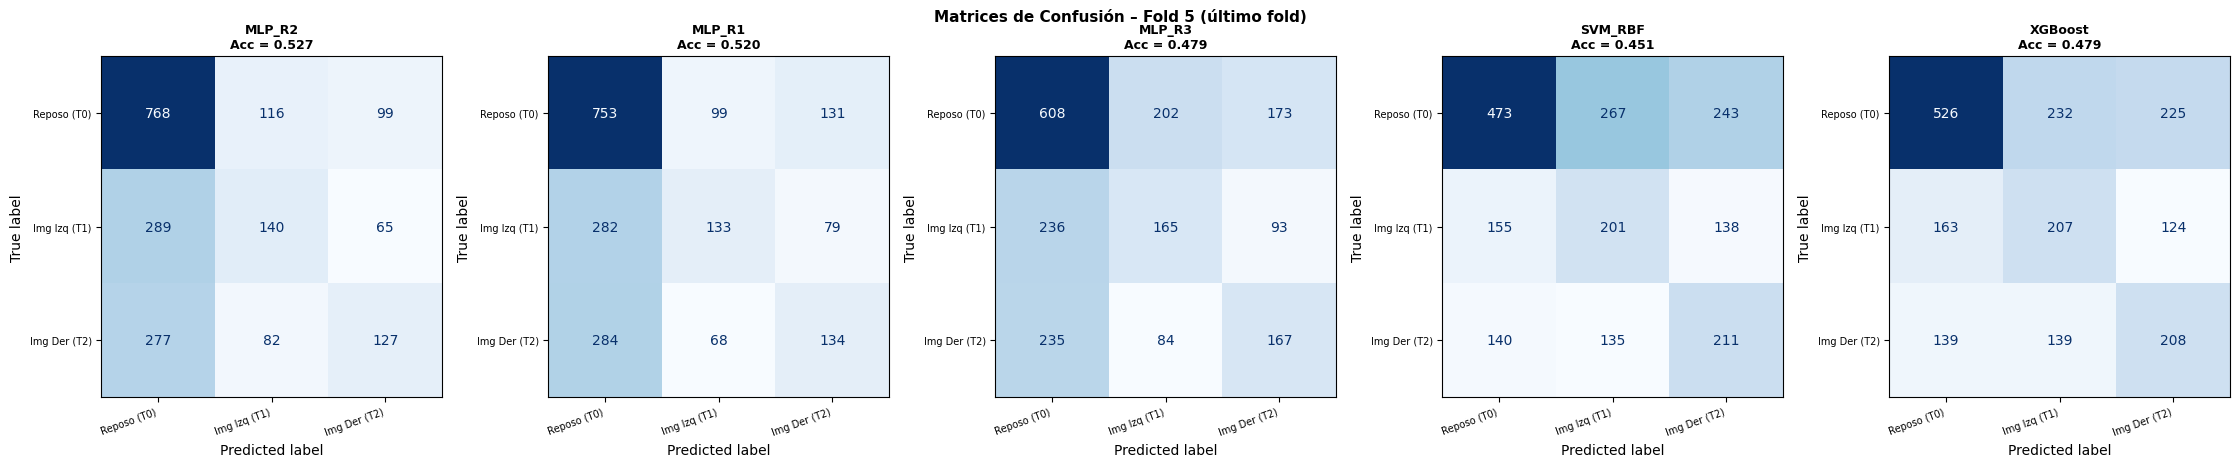

Figura guardada: figuras_P2/03_matrices_confusion.png


In [67]:
# Volvemos a obtener el último fold
splits = list(skf.split(X, y))
idx_tr_last, idx_te_last = splits[-1]

scaler_cm = StandardScaler()
X_tr_cm   = scaler_cm.fit_transform(X[idx_tr_last])
X_te_cm   = scaler_cm.transform(X[idx_te_last])

nombres_display = [NOMBRES_CLASE[0], NOMBRES_CLASE[1], NOMBRES_CLASE[2]]

n_modelos = len(modelos)
fig, axes = plt.subplots(1, n_modelos, figsize=(4.5 * n_modelos, 4.5))
if n_modelos == 1:
    axes = [axes]

sw_cm = compute_sample_weight('balanced', y[idx_tr_last])

for ax, (nombre, clf) in zip(axes, modelos.items()):
    if nombre in MODELOS_CON_SW:
        clf.fit(X_tr_cm, y[idx_tr_last], sample_weight=sw_cm)
    else:
        clf.fit(X_tr_cm, y[idx_tr_last])
    y_pred_cm = clf.predict(X_te_cm)

    cm  = confusion_matrix(y[idx_te_last], y_pred_cm)
    acc = accuracy_score(y[idx_te_last], y_pred_cm)

    ConfusionMatrixDisplay(cm, display_labels=nombres_display).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{nombre}\nAcc = {acc:.3f}', fontsize=9, fontweight='bold')
    ax.set_xticklabels(nombres_display, rotation=20, ha='right', fontsize=7)
    ax.set_yticklabels(nombres_display, fontsize=7)

fig.suptitle('Matrices de Confusión – Fold 5 (último fold)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/03_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras_P2/03_matrices_confusion.png')



## **14. Comparativa visual de todos los modelos**


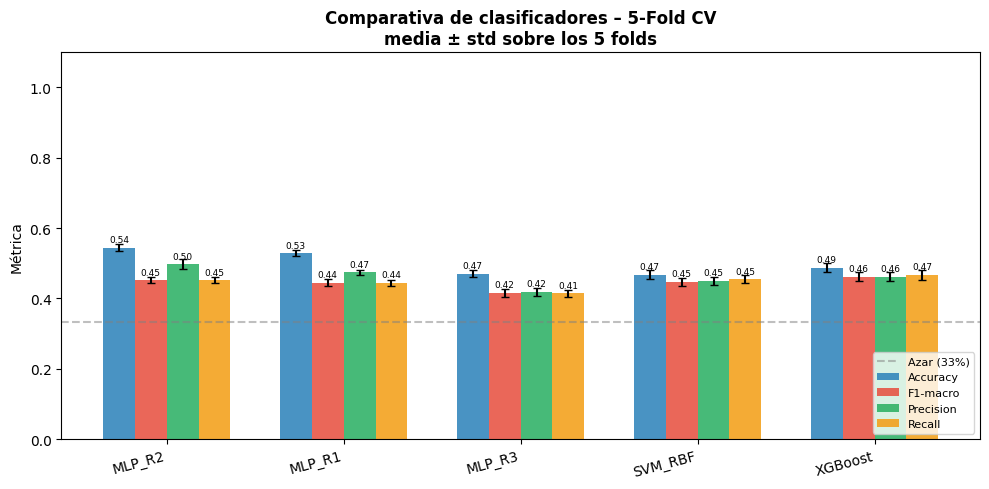

Figura guardada: figuras_P2/04_comparativa_modelos.png


In [68]:
nombres_modelos = list(resultados.keys())
metricas_keys   = ['acc', 'f1', 'prec', 'rec']
metricas_labels = ['Accuracy', 'F1-macro', 'Precision', 'Recall']
colores_bar     = ['#2980B9', '#E74C3C', '#27AE60', '#F39C12']

x     = np.arange(len(nombres_modelos))
ancho = 0.18

fig, ax = plt.subplots(figsize=(max(10, len(nombres_modelos)*2), 5))

for i, (key, label, color) in enumerate(zip(metricas_keys, metricas_labels, colores_bar)):
    medias = [np.mean(resultados[n][key]) for n in nombres_modelos]
    stds   = [np.std(resultados[n][key])  for n in nombres_modelos]
    offset = (i - 1.5) * ancho
    bars   = ax.bar(x + offset, medias, ancho,
                    yerr=stds, capsize=3,
                    label=label, color=color, alpha=0.85)
    for bar, m in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{m:.2f}', ha='center', va='bottom', fontsize=6.5)

ax.axhline(1/3, ls='--', color='gray', alpha=0.5, label='Azar (33%)')
ax.set_xticks(x)
ax.set_xticklabels(nombres_modelos, rotation=15, ha='right')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1.1)
ax.set_title('Comparativa de clasificadores – 5-Fold CV\n'
             'media ± std sobre los 5 folds',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('figuras_P2/04_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras_P2/04_comparativa_modelos.png')



## **15. SVM – ¿Cómo funciona?**

La **Máquina de Soporte Vectorial (SVM)** busca el hiperplano que mejor separa
dos clases maximizando el margen entre ellas. Los puntos más cercanos
a ese hiperplano se llaman *vectores de soporte*.

Cuando los datos **no son linealmente separables** (como suele pasar con EEG),
usamos el **kernel RBF** (Radial Basis Function):
$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$
Este kernel proyecta los datos a un espacio de mayor dimensión donde sí son
separables, sin calcular explícitamente esa proyección ('kernel trick').

Para problemas de 3 clases como el nuestro (T0, T1, T2), la SVM usa la
estrategia One-vs-One: entrena un clasificador binario para cada par de clases
(T0 vs T1, T0 vs T2, T1 vs T2) y elige por votación.

**Parámetros clave:**
- `C`: penalización por errores de clasificación. C alto → menos errores en train
  pero riesgo de overfitting.
- `gamma`: controla qué tan 'ancho' es el kernel RBF. `gamma='scale'` lo ajusta
  automáticamente según el número de features.


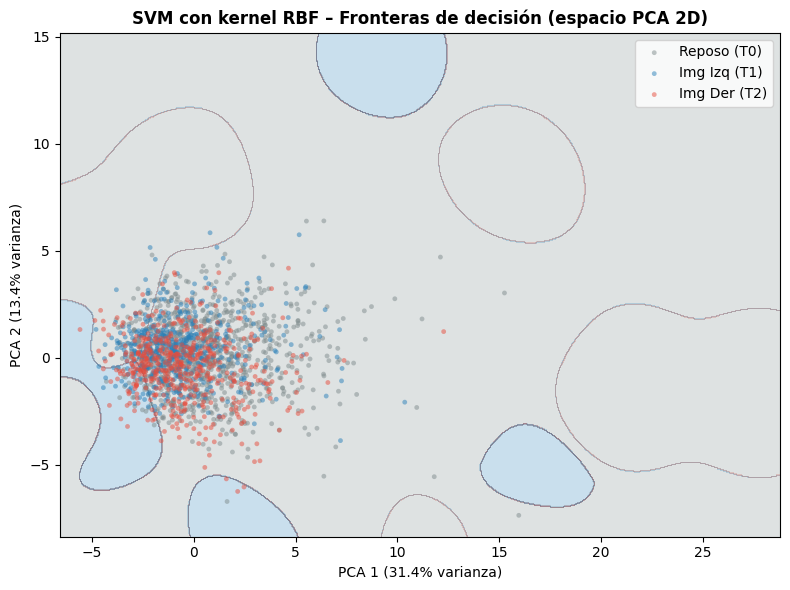

Accuracy SVM en 2D (solo referencia visual): 0.524


In [69]:
# -- Visualización 2D de la SVM (proyección PCA) ------------------
from sklearn.decomposition import PCA

scaler_svm = StandardScaler()
X_sc_svm   = scaler_svm.fit_transform(X)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sc_svm)

svm_demo = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_demo.fit(X_2d, y)

# Crear malla de decisión
h = 0.05
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = svm_demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25,
            colors=[COLORES_CLASE[0], COLORES_CLASE[1], COLORES_CLASE[2]])

# Puntar una muestra de puntos para no saturar el gráfico
n_plot = min(2000, len(X_2d))
idx_p  = np.random.choice(len(X_2d), n_plot, replace=False)
for c in [0, 1, 2]:
    mask = y[idx_p] == c
    ax.scatter(X_2d[idx_p][mask, 0], X_2d[idx_p][mask, 1],
               c=COLORES_CLASE[c], label=NOMBRES_CLASE[c],
               alpha=0.5, s=12, edgecolors='none')

ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('SVM con kernel RBF – Fronteras de decisión (espacio PCA 2D)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figuras_P2/05_svm_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Accuracy SVM en 2D (solo referencia visual): {svm_demo.score(X_2d, y):.3f}')



## **16. XGBoost  ¿Cómo funciona?**

**XGBoost (Extreme Gradient Boosting)** construye una serie de árboles de
decisión donde **cada árbol aprende de los errores del anterior**.
A eso se le llama *boosting* (a diferencia de Random Forest que entrena
todos los árboles en paralelo e independientemente).

La idea básica es:
1. El primer árbol intenta clasificar todas las épocas.
2. Calcula dónde se equivocó (el residuo o gradiente del error).
3. El segundo árbol solo intenta corregir esos errores.
4. Se repite T veces: $F_T(x) = F_{T-1}(x) + \eta \cdot h_T(x)$
   donde $\eta$ es el *learning rate* y $h_T$ es el árbol nuevo.

**Ventajas para BCI:**
- Maneja bien las no linealidades entre características EEG.
- Tiene regularización L1/L2 incorporada → menos overfitting.
- Puede ignorar automáticamente características poco útiles.


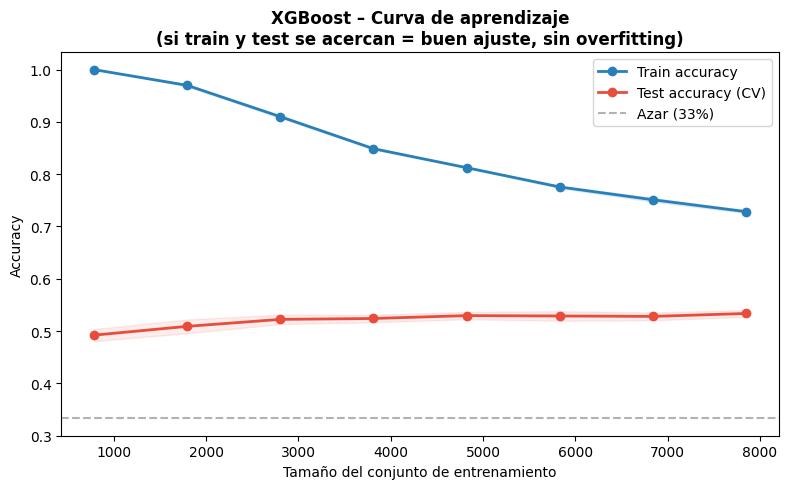

Figura guardada: figuras_P2/06_xgboost_learning_curve.png


In [70]:
# -- Ejemplo con XGBoost y curva de aprendizaje -------------------
if not XGB_OK:
    print('XGBoost no está instalado. Ejecutar: pip install xgboost')
else:
    from sklearn.model_selection import learning_curve

    scaler_xgb = StandardScaler()
    X_sc_xgb   = scaler_xgb.fit_transform(X)

    xgb_demo = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )

    skf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, tr_sc, te_sc = learning_curve(
        xgb_demo, X_sc_xgb, y, cv=skf_xgb,
        train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='accuracy', n_jobs=-1
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, tr_sc.mean(axis=1), 'o-', color='#2980B9',
            lw=2, label='Train accuracy')
    ax.fill_between(train_sizes,
                    tr_sc.mean(1) - tr_sc.std(1),
                    tr_sc.mean(1) + tr_sc.std(1), alpha=0.1, color='#2980B9')
    ax.plot(train_sizes, te_sc.mean(axis=1), 'o-', color='#E74C3C',
            lw=2, label='Test accuracy (CV)')
    ax.fill_between(train_sizes,
                    te_sc.mean(1) - te_sc.std(1),
                    te_sc.mean(1) + te_sc.std(1), alpha=0.1, color='#E74C3C')
    ax.axhline(1/3, ls='--', color='gray', alpha=0.6, label='Azar (33%)')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title('XGBoost – Curva de aprendizaje\n'
                 '(si train y test se acercan = buen ajuste, sin overfitting)',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('figuras_P2/06_xgboost_learning_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: figuras_P2/06_xgboost_learning_curve.png')



## **17. Red Neuronal MLP – Descripción y comparación de arquitecturas**

Un **Perceptrón Multicapa (MLP)** es una red de neuronas artificiales
organizadas en capas: entrada → capas ocultas → salida.

Cada neurona hace: $a = f\left(\sum_i w_i x_i + b\right)$
donde $f$ es la función de activación (ReLU o tanh en nuestro caso),
$w_i$ son los pesos (lo que la red aprende) y $b$ es el sesgo.

El entrenamiento ajusta los pesos mediante **backpropagation**:
calcula el error en la salida y lo propaga hacia atrás usando la regla
de la cadena para calcular cuánto contribuyó cada peso al error.

**Nuestras 3 arquitecturas:**
| Modelo | Capas ocultas | Activación | Observación |
| --- | --- | --- | --- |
| MLP_Simple | 64 → 32 | ReLU | Arquitectura básica de referencia |
| MLP_Profunda | 128 → 64 → 32 → 16 | ReLU + L2 | Más capas y regularización |
| MLP_Ancha | 256 → 128 | tanh | Menos capas pero más neuronas y tasa adaptativa |
